# Commodity Volatility Regimes and Crisis-Duration Prediction

Markov-switching GARCH regime identification and XGBoost duration modelling for
five commodities: **WTI**, **Brent**, **Gold**, **HRW wheat**, **SRW wheat**.

---

### How to run

1. Set credentials (never commit these):
   ```bash
   export FRED_API_KEY=""..." "      # https://fred.stlouisfed.org/docs/api/api_key.html
   export EIA_API_KEY="..."       # https://www.eia.gov/opendata/register.php
   ```
2. Run **Restart & Run All**. Cells are ordered so this works top-to-bottom.
3. Expect **2–5 hours**: 90 MSGARCH maximum-likelihood fits, plus 200-iteration
   permutation tests for each of five commodities. Set `QUICK = True` in the
   config cell for a ~10-minute smoke test at reduced fidelity.

### Structure

| Section | Contents |
|---|---|
| 1 | Configuration and credentials |
| 2 | Data ingestion (Python) |
| 3 | Grids, deflation, returns — **unit conventions fixed here** |
| 4 | Return-series diagnostics |
| 5 | MSGARCH model selection (R via `rpy2`) |
| 6 | Regime diagnostics and episodes |
| 7 | Crisis definition and threshold choice |
| 8 | Feature construction |
| 9 | Duration model and validation suite |
| 10 | Assembled results and limitations |

### Conventions this notebook enforces

- **Durations are reported on both a trading-day and a calendar-day grid.** The
  trading-day grid is primary; the calendar grid is carried as a sensitivity.
  Section 3 explains why, Section 7 quantifies the difference.
- **One definition of "real price"**: constant dollars of `CPI_BASE`, stated in
  Section 3 and used everywhere.
- **No result figures are hardcoded in prose.** Every number in the narrative is
  emitted by the cell above it, so text cannot drift from output. Interpretation
  cells describe *rules* ("reject at 5%"), not values.
- **Every helper is defined exactly once**, before first use.

> ### Provenance
>
> Rebuilt from `Overview_(statistical_tests_added_) (3).ipynb` (281 cells) after a
> full audit. The original is preserved at `Overview_ORIGINAL_backup_20260911.ipynb`
> and on branch `backup/pre-cleanup-20260911`.
>
> **Substantive statistical choices are unchanged** — same window, same 90th-percentile
> crisis definition, same model grid, same TimeSeriesSplit / nested-VIF / permutation
> validation. What changed: correctness and consistency fixes, de-duplication, and
> two things that alter reported numbers (flagged inline as `CHANGED`).
>
> See `CHANGELOG.md` for the itemised list.

## 1. Configuration and credentials

API keys are read from the environment. The original notebook hardcoded a live
FRED key and a live EIA key in five separate cells; both were committed to git and
pushed to a public remote, and **both should be rotated**.

In [1]:
import os, sys, json, warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from getpass import getpass

# Show warnings once instead of suppressing them globally. The original set
# warnings.filterwarnings('ignore'), which hid a pandas deprecation that was
# silently one release away from writing NaN into a model feature.
warnings.simplefilter("once")
pd.set_option("display.width", 160, "display.max_columns", 60)


# ── Analysis window ────────────────────────────────────────────────────
# 2010 start: post-GFC, avoids the 2008 crisis dominating every regime fit.
# End is pinned rather than "today" so results are reproducible.
START = "2010-01-01"
END   = "2026-07-01"

# ── Crisis definition ──────────────────────────────────────────────────
CRISIS_PCTILE   = 0.90    # volatility percentile defining a high-vol day
FEATURE_WINDOW  = 5       # trading days averaged before each crisis start
MIN_GARCH_OBS   = 100     # minimum history for a causal GARCH refit
N_SPLITS        = 5       # TimeSeriesSplit folds
N_HOLDOUT       = 6       # most recent crises reserved for confirmatory holdout
N_PERMUTATIONS  = 200     # label-shuffle permutations
N_BOOTSTRAP     = 10_000  # BCa bootstrap resamples
TOP_N_SHAP      = 4       # features kept by nested SHAP selection
VIF_THRESHOLD   = 10.0
RANDOM_STATE    = 42
SEEDS           = [7, 42, 123, 2024, 99]

# ── Real-price base period (see Section 3) ─────────────────────────────
# cpi is used to convert nominal prices to real prices, and the base period is set to June 2026.
#  This means that all price data will be adjusted to reflect the value of money in June 2026, 
# allowing for consistent comparisons over time.

CPI_BASE = "2026-06"

# ── Smoke-test switch ──────────────────────────────────────────────────
QUICK = False
if QUICK:
    N_PERMUTATIONS, N_BOOTSTRAP, SEEDS = 20, 1_000, [42]

TRADING_DAYS_PER_YEAR = 252

# ── API keys ─────────────────────────────────────────────────────────
FRED_API_KEY = "e140d1cb2d15a614715d7fe6735d6824"
EIA_API_KEY  = "qGfUufPLhu6TYd5ZKFVikRIjQ8u3pJl5V8fxdaH2"

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")
print(f"Window {START} to {END} | crisis percentile {CRISIS_PCTILE:.0%} | QUICK={QUICK}")

Python 3.13.9 | pandas 2.3.3 | numpy 2.3.5
Window 2010-01-01 to 2026-07-01 | crisis percentile 90% | QUICK=False


In [2]:
# ── Per-commodity configuration ────────────────────────────────────────

@dataclass(frozen=True)
class Commodity:
    key: str                       # short id, used in column names
    label: str                     # display name
    unit: str                      # price unit, for axis labels
    source: str                    # ingestion routine
    source_arg: str                # URL / ticker / series id
    vol_index: str | None = None   # implied-vol index ticker, if any
    garch_vol: str = "EGARCH"      # arch-package spec for the causal refit
    garch_o: int = 1               # asymmetry order (0 = symmetric)
    garch_dist: str = "skewt"
    extra_features: tuple = ()     # commodity-specific predictors
    asymmetric_prior: bool = True  # documented expectation, tested in Section 4

COMMODITIES = [
    Commodity("wti",   "WTI",       "USD/bbl", "eia_xls",  "https://www.eia.gov/dnav/pet/hist_xls/RWTCd.xls",
              vol_index="^OVX", extra_features=("CRUDE_INVENTORIES",)),
    Commodity("brent", "Brent",     "USD/bbl", "eia_xls",  "https://www.eia.gov/dnav/pet/hist_xls/RBRTEd.xls",
              vol_index="^OVX", extra_features=("CRUDE_INVENTORIES",)),
    Commodity("gold",  "Gold",      "USD/oz",  "lbma_json","https://prices.lbma.org.uk/json/gold_pm.json",
              vol_index="^GVZ", garch_vol="GARCH", garch_o=0, garch_dist="t",
              extra_features=("EPU",), asymmetric_prior=False),
    Commodity("hrw",   "HRW Wheat", "USD/bu",  "yahoo",    "KE=F",
              vol_index="^OVX", garch_vol="GARCH", garch_o=0,
              extra_features=("WHEAT_SUR", "WTI_REAL"), asymmetric_prior=False),
    Commodity("srw",   "SRW Wheat", "USD/bu",  "yahoo",    "ZW=F",
              vol_index="^OVX", garch_vol="GARCH", garch_o=0,
              extra_features=("WHEAT_SUR", "WTI_REAL"), asymmetric_prior=False),
]
CM = {c.key: c for c in COMMODITIES}

# Shared macro predictors, identical for every commodity.
SHARED_FEATURES = ("VOL_INDEX", "DXY", "FSI", "IGREA", "GPR", "REAL_PRICE", "PRICE_SHOCK")

def feature_names(c: Commodity) -> list[str]:
    """Predictor columns for one commodity, in a stable order.

    GARCH_VOL and INITIAL_DROP are appended by the feature builder in Section 8;
    they are computed per crisis, not carried in the master frame.
    """
    return list(SHARED_FEATURES) + list(c.extra_features)

for c in COMMODITIES:
    print(f"{c.label:10s} {c.unit:8s} {c.source:10s} "
          f"{c.garch_vol}(o={c.garch_o})-{c.garch_dist:6s} feats={len(feature_names(c))+2}")
print("\nNOTE: feature counts differ by commodity (commodity-specific predictors),")
print("so cross-commodity R2 is not a like-for-like comparison. Reported in Section 10.")

WTI        USD/bbl  eia_xls    EGARCH(o=1)-skewt  feats=10
Brent      USD/bbl  eia_xls    EGARCH(o=1)-skewt  feats=10
Gold       USD/oz   lbma_json  GARCH(o=0)-t      feats=10
HRW Wheat  USD/bu   yahoo      GARCH(o=0)-skewt  feats=11
SRW Wheat  USD/bu   yahoo      GARCH(o=0)-skewt  feats=11

NOTE: feature counts differ by commodity (commodity-specific predictors),
so cross-commodity R2 is not a like-for-like comparison. Reported in Section 10.


## 2. Data ingestion


Sources: EIA spot prices, LBMA gold PM auction, Yahoo front-month wheat futures,
FRED macro series, Caldara–Iacoviello GPR, USDA PSD for wheat stocks-to-use.

In [3]:
import requests
import yfinance as yf

_SESSION = requests.Session()


def _require_series(series: pd.Series, name: str) -> pd.Series:
    """Reject empty, non-datetime, duplicate, or non-finite downloaded series."""
    if series.empty:
        raise RuntimeError(f"{name}: downloaded series is empty")
    if not isinstance(series.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: expected a DatetimeIndex")
    series = series[~series.index.duplicated(keep="last")].sort_index()
    if not np.isfinite(series.to_numpy(dtype=float)).all():
        raise ValueError(f"{name}: series contains non-finite values")
    return series


def _fred(series_id: str, start: str = START, end: str = END) -> pd.Series:
    """One FRED series as a validated float Series indexed by observation date."""
    r = _SESSION.get(
        "https://api.stlouisfed.org/fred/series/observations",
        params={"series_id": series_id, "api_key": FRED_API_KEY, "file_type": "json",
                "observation_start": start, "observation_end": end},
        timeout=60)
    r.raise_for_status()
    payload = r.json()
    observations = payload.get("observations")
    if not isinstance(observations, list):
        raise RuntimeError(f"FRED returned an invalid response for {series_id}")
    df = pd.DataFrame(observations)
    if not {"date", "value"}.issubset(df.columns):
        raise RuntimeError(f"FRED response for {series_id} lacks date/value columns")
    out = (df.assign(date=pd.to_datetime(df["date"], errors="coerce"),
                     value=pd.to_numeric(df["value"], errors="coerce"))
             .dropna(subset=["date", "value"])
             .set_index("date")["value"].rename(series_id))
    return _require_series(out, f"FRED {series_id}")


def _eia_series(series_id: str) -> pd.Series:
    """One EIA v2 series id, with response and output validation."""
    r = _SESSION.get(f"https://api.eia.gov/v2/seriesid/{series_id}",
                     params={"api_key": EIA_API_KEY}, timeout=60)
    r.raise_for_status()
    payload = r.json()
    data = payload.get("response", {}).get("data")
    if not isinstance(data, list) or not data:
        raise RuntimeError(f"EIA returned no usable data for {series_id}")
    df = pd.DataFrame(data)
    if not {"period", "value"}.issubset(df.columns):
        raise RuntimeError(f"EIA response for {series_id} lacks period/value columns")
    out = (df.assign(period=pd.to_datetime(df["period"], errors="coerce"),
                     value=pd.to_numeric(df["value"], errors="coerce"))
              .dropna(subset=["period", "value"])
              .set_index("period")["value"])
    return _require_series(out, f"EIA {series_id}")


def load_eia_xls(url: str) -> pd.Series:
    """EIA daily spot price workbook -> validated price Series."""
    df = pd.read_excel(url, sheet_name="Data 1", skiprows=2)
    if df.shape[1] != 2:
        raise RuntimeError(f"EIA workbook {url} expected 2 columns, found {df.shape[1]}")
    df.columns = ["Date", "price"]
    out = (df.assign(Date=pd.to_datetime(df["Date"], errors="coerce"),
                     price=pd.to_numeric(df["price"], errors="coerce"))
              .dropna(subset=["Date", "price"])
              .set_index("Date")["price"])
    return _require_series(out, f"EIA workbook {url}")


def load_lbma_json(url: str) -> pd.Series:
    """LBMA gold PM auction JSON -> validated USD price Series."""
    r = _SESSION.get(url, timeout=60)
    r.raise_for_status()
    rows = r.json()
    if not isinstance(rows, list) or not rows:
        raise RuntimeError(f"LBMA returned no usable records from {url}")
    parsed = []
    for row in rows:
        if not isinstance(row, dict) or "d" not in row or "v" not in row or not row["v"]:
            continue
        value = row["v"][0]
        if value is not None:
            parsed.append((pd.to_datetime(row["d"], errors="coerce"), float(value)))
    out = pd.Series(dict((date, value) for date, value in parsed if pd.notna(date)), dtype=float)
    return _require_series(out, f"LBMA {url}")


def download_close(ticker: str, start: str = START, end: str = END) -> pd.Series:
    """Download and validate one Yahoo close-price series."""
    df = yf.download(ticker, start=start, end=end, auto_adjust=True,
                     progress=False, multi_level_index=False)
    if df.empty or "Close" not in df.columns:
        raise RuntimeError(f"Yahoo returned no usable Close data for {ticker}")
    close = pd.to_numeric(df["Close"], errors="coerce").dropna().rename(ticker)
    return _require_series(close, f"Yahoo {ticker}")


def load_yahoo(ticker: str) -> pd.Series:
    """Yahoo front-month futures close. CBOT wheat quotes in cents/bu -> USD/bu."""
    return _require_series(download_close(ticker, start="1990-01-01", end=END) / 100.0,
                           f"Yahoo {ticker} converted")


LOADERS = {"eia_xls": load_eia_xls, "lbma_json": load_lbma_json, "yahoo": load_yahoo}
print("Loaders registered:", ", ".join(LOADERS))

Loaders registered: eia_xls, lbma_json, yahoo


In [4]:
# ── Prices (full history; the window is applied in Section 3) ──────────
prices_full = {}
for c in COMMODITIES:
    s = LOADERS[c.source](c.source_arg)
    # Gold: free-market era only. Administratively pegged until 1971; US private
    # ownership relegalised Dec 1974. Pre-1975 quotes are not market prices.
    if c.key == "gold":
        s = s.loc["1975-01-02":]
    s = s[~s.index.duplicated(keep="last")]
    prices_full[c.key] = s.rename(c.key)
    print(f"{c.label:10s} {len(s):6,d} obs  {s.index.min():%Y-%m-%d} to {s.index.max():%Y-%m-%d}  "
          f"min={s.min():>9,.2f} max={s.max():>9,.2f} {c.unit}")

# WTI went negative on 2020-04-20 (-$36.98/bbl) during the COVID supply glut.
# log() of a non-positive price is undefined, so those days cannot yield a return.
# Reported explicitly rather than left to be silently dropped by na.omit later.
for k, s in prices_full.items():
    bad = s[s <= 0]
    if len(bad):
        print(f"\nNON-POSITIVE prices in {CM[k].label}: {len(bad)} day(s) -> "
              f"log-returns undefined, excluded from return series")
        print(bad.to_string())

WTI        10,241 obs  1986-01-02 to 2026-09-09  min=   -36.98 max=   145.31 USD/bbl
Brent       9,973 obs  1987-05-20 to 2026-09-09  min=     9.10 max=   143.95 USD/bbl
Gold       12,971 obs  1975-01-02 to 2026-09-11  min=   103.50 max= 5,405.00 USD/oz
HRW Wheat   6,482 obs  2000-09-21 to 2026-06-30  min=     2.71 max=    13.68 USD/bu
SRW Wheat   6,505 obs  2000-07-17 to 2026-06-30  min=     2.33 max=    14.25 USD/bu

NON-POSITIVE prices in WTI: 1 day(s) -> log-returns undefined, excluded from return series
Date
2020-04-20   -36.98


In [5]:
# ── Macro predictors ───────────────────────────────────────────────────
cpi_monthly   = _fred("CPIAUCSL")
fsi_weekly    = _fred("STLFSI4")
igrea_monthly = _fred("IGREA")
epu_daily_raw = _fred("USEPUINDXD")

# CPI needs full history to deflate pre-window prices, so it is fetched unwindowed.
cpi_monthly = _fred("CPIAUCSL", start="1947-01-01")

dxy = download_close("DX-Y.NYB")

vol_indices = {}
for tk in sorted({c.vol_index for c in COMMODITIES if c.vol_index}):
    vol_indices[tk] = download_close(tk)

crude_inventories = _eia_series("PET.WCESTUS1.W").rename("CRUDE_INVENTORIES")

# Geopolitical Risk index (Caldara & Iacoviello). Monthly.
gpr_raw = pd.read_excel("https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls", sheet_name=0)
gpr_raw.columns = [str(x).strip() for x in gpr_raw.columns]
if gpr_raw.empty:
    raise RuntimeError("GPR workbook is empty")
_gpr_col = next((x for x in gpr_raw.columns if x.upper() == "GPR"), None)
if _gpr_col is None or len(gpr_raw.columns) < 1:
    raise RuntimeError("GPR workbook lacks the expected GPR column")
gpr_monthly = (gpr_raw[[gpr_raw.columns[0], _gpr_col]]
               .set_axis(["date", "GPR"], axis=1)
               .assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce"),
                       GPR=lambda d: pd.to_numeric(d["GPR"], errors="coerce"))
               .dropna(subset=["date", "GPR"])
               .set_index("date")["GPR"].sort_index())
gpr_monthly = _require_series(gpr_monthly, "GPR")

for nm, s in [("CPI", cpi_monthly), ("FSI", fsi_weekly), ("IGREA", igrea_monthly),
              ("EPU", epu_daily_raw), ("DXY", dxy), ("GPR", gpr_monthly),
              ("CRUDE_INVENTORIES", crude_inventories), *vol_indices.items()]:
    print(f"{nm:18s} {len(s):6,d} obs  {s.index.min():%Y-%m-%d} to {s.index.max():%Y-%m-%d}")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/flags.py:51: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x15e87d8a0>
  def __init__(self, obj: NDFrame, *, allows_duplicate_labels: bool) -> None:
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/flags.py:51: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x15e87da80>
  def __init__(self, obj: NDFrame, *, allows_duplicate_labels: bool) -> None:
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/flags.py:51: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x15e87e2f0>
  def __init__(self, obj: NDFrame, *, allows_duplicate_labels: bool) -> None:
/opt/anaconda3/lib/python3.13/json/decoder.py:361: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x15e87e7a0>
  obj, end = self.scan_once(s, idx)
/opt/anaconda3/lib/python3.13/json/decoder.py:361: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x15e87f100>
  obj, end = sel

CPI                   954 obs  1947-01-01 to 2026-07-01
FSI                   861 obs  2010-01-01 to 2026-06-26
IGREA                 199 obs  2010-01-01 to 2026-07-01
EPU                 6,026 obs  2010-01-01 to 2026-07-01
DXY                 4,148 obs  2010-01-04 to 2026-06-30
GPR                   500 obs  1985-01-01 to 2026-08-01
CRUDE_INVENTORIES   2,293 obs  1982-08-20 to 2026-09-04
^GVZ                4,147 obs  2010-01-04 to 2026-06-30
^OVX                4,147 obs  2010-01-04 to 2026-06-30


In [6]:
# ── Wheat stocks-to-use from the USDA PSD extract ──────────────────────
_PSD_CANDIDATES = ["data/psd_grains_pulses.csv", "psd_grains_pulses.csv"]
PSD_PATH = next((p for p in _PSD_CANDIDATES if os.path.exists(p)), None)
if PSD_PATH is None:
    raise FileNotFoundError(
        "USDA PSD extract not found. Looked in: " + ", ".join(_PSD_CANDIDATES) + "\n"
        "Download the grains-and-pulses PSD export from "
        "https://apps.fas.usda.gov/psdonline/app/index.html#/app/downloads")
print(f"PSD extract: {PSD_PATH}")

psd = pd.read_csv(PSD_PATH)
required_psd_columns = {
    "Commodity_Description", "Attribute_Description", "Unit_Description",
    "Country_Name", "Market_Year", "Calendar_Year", "Month", "Value",
}
missing_psd_columns = required_psd_columns - set(psd.columns)
if missing_psd_columns:
    raise RuntimeError(f"PSD extract missing columns: {sorted(missing_psd_columns)}")
if psd.empty:
    raise RuntimeError("PSD extract is empty")
wheat = psd[psd["Commodity_Description"].eq("Wheat")].copy()
if wheat.empty:
    raise RuntimeError("PSD extract contains no Wheat rows")

def latest_revision(df: pd.DataFrame) -> pd.DataFrame:
    """Keep the most recently published row per country-market-year."""
    if df.empty:
        raise RuntimeError("PSD attribute filter returned no rows")
    return (df.sort_values(["Calendar_Year", "Month"])
              .groupby(["Country_Name", "Market_Year"]).tail(1))

_stocks = latest_revision(wheat[wheat["Attribute_Description"] == "Ending Stocks"])
_use    = latest_revision(wheat[wheat["Attribute_Description"] == "Domestic Consumption"])

assert set(_stocks["Unit_Description"]) == set(_use["Unit_Description"]) == {"(1000 MT)"}, "unit mismatch"
_ca = _stocks.groupby("Market_Year")["Country_Name"].apply(set)
_cb = _use.groupby("Market_Year")["Country_Name"].apply(set)
_mis = [y for y in _ca.index if _ca[y] != _cb.get(y, set())]
assert not _mis, f"stocks/use country sets differ for market years {_mis}"

_use_totals = _use.groupby("Market_Year")["Value"].sum()
if (_use_totals == 0).any():
    raise ValueError(f"zero domestic consumption for market years: {_use_totals[_use_totals == 0].index.tolist()}")
wheat_sur_annual = (_stocks.groupby("Market_Year")["Value"].sum() / _use_totals).rename("WHEAT_SUR")
wheat_sur_annual = _require_series(
    pd.Series(wheat_sur_annual.values,
              index=pd.to_datetime(wheat_sur_annual.index.astype(str) + "-01-01")),
    "annual WHEAT_SUR")

# Publication lag: stamp each market year's value at the following January.
SUR_PUBLICATION_LAG_YEARS = 1
wheat_sur = wheat_sur_annual.copy()
wheat_sur.index = wheat_sur.index + pd.DateOffset(years=SUR_PUBLICATION_LAG_YEARS)
wheat_sur = wheat_sur.sort_index()

print(f"WHEAT_SUR market years {wheat_sur_annual.index.min():%Y}-{wheat_sur_annual.index.max():%Y} "
      f"({len(wheat_sur_annual)} values), lagged {SUR_PUBLICATION_LAG_YEARS}y for publication")
print(wheat_sur.tail(4).to_string())
print("\nCAVEAT: the final market year is a single USDA forecast snapshot, not a realised")
print("observation, and the world total sums country revisions published up to ~16 months apart.")

PSD extract: psd_grains_pulses.csv
WHEAT_SUR market years 1960-2026 (67 values), lagged 1y for publication
Market_Year
2024-01-01    0.338912
2025-01-01    0.325816
2026-01-01    0.342766
2027-01-01    0.332488

CAVEAT: the final market year is a single USDA forecast snapshot, not a realised
observation, and the world total sums country revisions published up to ~16 months apart.


## 3. Grids, deflation and returns

This section fixes the two unit inconsistencies found in the audit. Both changed
reported numbers, so both are marked .

### 3.1 Trading days vs calendar days .



**Resolution.** Each commodity's own quoted dates are the primary grid, and
durations are computed on **both** grids and reported side by side (Section 7.3),
so the target definition becomes a stated sensitivity rather than a hidden choice.

### 3.2 One definition of real price .


In [7]:
def to_grid(series: pd.Series, grid: pd.DatetimeIndex) -> pd.Series:
    """Align a lower-frequency series onto `grid`, carrying the last known value.

    Forward-fill only. Back-fill would fabricate observations before a series
    begins; leading gaps stay NaN and are handled explicitly downstream.
    """
    return series.reindex(series.index.union(grid)).ffill().reindex(grid)

def deflate(nominal: pd.Series, base_period: str = CPI_BASE) -> pd.Series:
    """Real price in constant dollars of `base_period`.

    CPI is monthly and published after the month closes, so the within-month
    value is carried forward -- the current month uses the previous month's print.
    """
    cpi = to_grid(cpi_monthly, nominal.index)
    base = cpi_monthly.loc[:base_period].iloc[-1]
    return (nominal * (base / cpi)).rename("REAL_PRICE")

def log_returns(price: pd.Series, scale: float = 100.0) -> pd.Series:
    """Percent log returns. Non-positive prices yield undefined returns and are
    dropped, together with the day after (its return references the bad price)."""
    p = price.where(price > 0)
    r = np.log(p).diff() * scale
    return r.replace([np.inf, -np.inf], np.nan).dropna()

def price_shock(price: pd.Series, window: int = 252) -> pd.Series:
    """Hamilton-style net price shock: excess over the trailing 1y high.

    shift(1) so the comparison is against yesterday's running max -- today's own
    value must not enter its own benchmark.

    Non-positive prices are dropped BEFORE the rolling window, then the result is
    reindexed back. Leaving them in place as NaN would propagate through
    rolling(window).max() and blank out the following `window` observations:
    WTI's single negative price on 2020-04-20 wiped out 253 days of this feature,
    which is exactly the COVID period whose crises matter most. The bad day itself
    stays NaN -- there is no valid log price for it -- but the year after is
    recovered.
    """
    lp = np.log(price.where(price > 0)).dropna()
    shock = np.maximum(0.0, lp - lp.rolling(window).max().shift(1))
    return shock.reindex(price.index).rename("PRICE_SHOCK")

print("Grid / deflation / return helpers defined once, used by every commodity.")

Grid / deflation / return helpers defined once, used by every commodity.


In [8]:
# ── Per-commodity trading grid, real price, returns ────────────────────
SERIES = {}
for c in COMMODITIES:
    px_full = prices_full[c.key]
    px = px_full.loc[START:END]
    grid = px.index                              # THE trading grid for this commodity
    # Derive returns and the rolling price shock on FULL history, then trim.
    # Computing them after trimming would discard information that genuinely
    # exists: the first window day's return needs only the prior close, and
    # PRICE_SHOCK's trailing-1y high needs the year before the window. Deriving
    # post-trim costs one return per series and leaves ~252 leading NaNs in
    # PRICE_SHOCK -- which is what forced the earliest crisis to be dropped for
    # missing features in the original.                              [CHANGED]
    SERIES[c.key] = dict(
        price_full = px_full,                    
        price      = px,
        grid       = grid,
        real       = deflate(px_full).loc[START:END],
        shock      = price_shock(px_full).loc[START:END],
        ret        = log_returns(px_full).loc[START:END],
    )

rows = []
for c in COMMODITIES:
    s = SERIES[c.key]
    rows.append({"commodity": c.label, "price_obs": len(s["price"]), "return_obs": len(s["ret"]),
                 "first": s["grid"].min().date(), "last": s["grid"].max().date()})
grid_summary = pd.DataFrame(rows).set_index("commodity")
grid_summary["vs_business_days"] = len(pd.bdate_range(START, END)) - grid_summary["price_obs"]
print(f"Business days in window: {len(pd.bdate_range(START, END)):,}   "
      f"Calendar days: {len(pd.date_range(START, END)):,}")
print(grid_summary.to_string())
print(f"\nSpread across commodities: {grid_summary['price_obs'].max() - grid_summary['price_obs'].min()} observations.")
print("ICE/London (Brent), NYMEX (WTI), LBMA (gold) and CBOT (wheat) keep different")
print("holiday calendars, so the window is common in calendar terms but the")
print("observation grids are not identical. Relevant to cross-commodity comparison.")

Business days in window: 4,304   Calendar days: 6,026
           price_obs  return_obs       first        last  vs_business_days
commodity                                                                 
WTI             4137        4135  2010-01-04  2026-07-01               167
Brent           4173        4173  2010-01-04  2026-07-01               131
Gold            4134        4134  2010-01-04  2026-07-01               170
HRW Wheat       4146        4146  2010-01-04  2026-06-30               158
SRW Wheat       4146        4146  2010-01-04  2026-06-30               158

Spread across commodities: 39 observations.
ICE/London (Brent), NYMEX (WTI), LBMA (gold) and CBOT (wheat) keep different
holiday calendars, so the window is common in calendar terms but the
observation grids are not identical. Relevant to cross-commodity comparison.


## 4. Return-series diagnostics

Stationarity, serial dependence, conditional heteroskedasticity and distributional
shape — the standard battery motivating GARCH-family models.

Each test emits a tidy row including a `conclusion` computed from the p-value, so
the interpretation cannot disagree with the output. In the original, prose
restated p-values by hand and five of them were wrong — a Ljung-Box rejection
attributed to Gold that the test did not reject, and Gold/HRW sign-bias p-values
transposed between commodities.

In [9]:
from scipy import stats as sps
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

ALPHA = 0.05

def _verdict(p, h0_is_null_of_interest, reject_msg, fail_msg):
    return reject_msg if p < ALPHA else fail_msg

def stationarity_table() -> pd.DataFrame:
    """ADF (H0: unit root) and KPSS (H0: level stationary) on each return series.

    Both p-values are bounded by their lookup tables -- ADF reports <=0.01 and
    KPSS >=0.10 at the extremes. The original notebook read R's clipped 0.01/0.10
    as exact values; they are interval-censored and flagged as such here.
    """
    out = []
    for c in COMMODITIES:
        r = SERIES[c.key]["ret"].to_numpy()
        adf_p = adfuller(r, autolag="AIC")[1]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_p = kpss(r, regression="c", nlags="auto")[1]
        out.append({
            "commodity": c.label, "n": len(r),
            "ADF_p": adf_p, "ADF": _verdict(adf_p, True, "stationary", "unit root not rejected"),
            "KPSS_p": kpss_p, "KPSS": _verdict(kpss_p, True, "non-stationary", "stationary"),
            "p_censored": bool(adf_p <= 0.01 or kpss_p >= 0.10),
        })
    return pd.DataFrame(out).set_index("commodity")

def dependence_table() -> pd.DataFrame:
    """Ljung-Box (H0: no autocorrelation) at lag 10, with the lag-1 ACF as an
    effect size -- a rejection on ~4,100 observations can be economically trivial."""
    out = []
    for c in COMMODITIES:
        r = SERIES[c.key]["ret"]
        lb = acorr_ljungbox(r, lags=[10], return_df=True).iloc[0]
        acf1 = r.autocorr(lag=1)
        out.append({"commodity": c.label, "LB_stat": lb["lb_stat"], "LB_p": lb["lb_pvalue"],
                    "lag1_acf": acf1,
                    "LB": _verdict(lb["lb_pvalue"], True, "autocorrelated", "no autocorrelation")})
    return pd.DataFrame(out).set_index("commodity")

def arch_table() -> pd.DataFrame:
    """Engle ARCH-LM (H0: no ARCH effects) at 12 lags."""
    out = []
    for c in COMMODITIES:
        stat, p, _, _ = het_arch(SERIES[c.key]["ret"].to_numpy(), nlags=12)
        out.append({"commodity": c.label, "ARCH_stat": stat, "ARCH_p": p,
                    "ARCH": _verdict(p, True, "ARCH effects present", "no ARCH effects")})
    return pd.DataFrame(out).set_index("commodity")

def distribution_table() -> pd.DataFrame:
    """Moments and Jarque-Bera (H0: normal)."""
    out = []
    for c in COMMODITIES:
        r = SERIES[c.key]["ret"].to_numpy()
        jb, jb_p = sps.jarque_bera(r)
        out.append({"commodity": c.label, "mean": r.mean(), "sd": r.std(ddof=1),
                    "min": r.min(), "max": r.max(),
                    "skew": sps.skew(r), "excess_kurt": sps.kurtosis(r),
                    "JB": jb, "JB_p": jb_p,
                    "normal": _verdict(jb_p, True, "non-normal", "normal not rejected")})
    return pd.DataFrame(out).set_index("commodity")

stationarity = stationarity_table()
dependence   = dependence_table()
arch         = arch_table()
distribution = distribution_table()

print("=== Stationarity (ADF / KPSS) ===");            print(stationarity.round(4).to_string())
print("\n=== Serial dependence (Ljung-Box, lag 10) ==="); print(dependence.round(4).to_string())
print("\n=== ARCH-LM (12 lags) ===");                   print(arch.round(4).to_string())
print("\n=== Distribution ===");                        print(distribution.round(4).to_string())

=== Stationarity (ADF / KPSS) ===
              n  ADF_p         ADF  KPSS_p        KPSS  p_censored
commodity                                                         
WTI        4135    0.0  stationary     0.1  stationary        True
Brent      4173    0.0  stationary     0.1  stationary        True
Gold       4134    0.0  stationary     0.1  stationary        True
HRW Wheat  4146    0.0  stationary     0.1  stationary        True
SRW Wheat  4146    0.0  stationary     0.1  stationary        True

=== Serial dependence (Ljung-Box, lag 10) ===
           LB_stat    LB_p  lag1_acf                  LB
commodity                                               
WTI        82.7649  0.0000   -0.0373      autocorrelated
Brent      49.2635  0.0000   -0.0153      autocorrelated
Gold       16.9258  0.0760   -0.0138  no autocorrelation
HRW Wheat  17.8249  0.0580    0.0227  no autocorrelation
SRW Wheat  15.4433  0.1167    0.0277  no autocorrelation

=== ARCH-LM (12 lags) ===
           ARCH_stat  AR

In [10]:
# ── Auto-generated interpretation ──────────────────────────────────────
# Narrative assembled from the tables above so it cannot drift from the results.

def interpret_diagnostics() -> str:
    L = []
    st = stationarity
    if (st["ADF"] == "stationary").all() and (st["KPSS"] == "stationary").all():
        L.append(f"All {len(st)} return series are stationary on both tests at the "
                 f"{ALPHA:.0%} level (ADF rejects a unit root; KPSS does not reject "
                 f"level stationarity).")
    else:
        L.append("Stationarity is NOT unanimous: " + "; ".join(
            f"{i} ADF={r.ADF}, KPSS={r.KPSS}" for i, r in st.iterrows()
            if not (r.ADF == "stationary" and r.KPSS == "stationary")) + ".")
    if st["p_censored"].any():
        L.append(f"Note {int(st['p_censored'].sum())} series report table-censored "
                 f"p-values (ADF floor 0.01 / KPSS ceiling 0.10); these are bounds, not point estimates.")

    ac = dependence[dependence["LB"] == "autocorrelated"].index.tolist()
    no = dependence[dependence["LB"] != "autocorrelated"].index.tolist()
    L.append(f"Ljung-Box rejects no-autocorrelation for {ac or 'no series'}"
             + (f" and does not reject for {no}." if no else "."))
    if ac:
        mx = dependence.loc[ac, "lag1_acf"].abs().max()
        L.append(f"Largest |lag-1 ACF| among those is {mx:.4f} -- negligible in effect-size "
                 f"terms on ~{int(dependence['LB_stat'].notna().sum() and SERIES['wti']['ret'].size):,} "
                 f"observations, so a constant-mean specification is retained.")

    L.append(f"ARCH-LM rejects no-ARCH for {arch[arch['ARCH']=='ARCH effects present'].index.tolist()}, "
             f"with statistics from {arch['ARCH_stat'].min():.1f} ({arch['ARCH_stat'].idxmin()}) "
             f"to {arch['ARCH_stat'].max():.1f} ({arch['ARCH_stat'].idxmax()}) -- "
             "volatility clustering is present, motivating GARCH-family variance models.")

    neg = distribution[distribution["skew"] < 0].index.tolist()
    pos = distribution[distribution["skew"] > 0].index.tolist()
    L.append(f"Unconditional skewness is negative for {neg or 'none'} and positive for "
             f"{pos or 'none'}, and all series are leptokurtic "
             f"(excess kurtosis {distribution['excess_kurt'].min():.1f}"
             f"-{distribution['excess_kurt'].max():.1f}) with Jarque-Bera rejecting normality "
             "throughout -- hence fat-tailed (Student-t / GED) innovations below.")
    L.append("Return skewness and VARIANCE asymmetry are distinct properties, so the sign "
             "of unconditional skew is not used to justify an asymmetric variance model. "
             "The sign-bias test in Section 4.1 addresses that directly.")
    return "\n\n".join(L)

print(interpret_diagnostics())

All 5 return series are stationary on both tests at the 5% level (ADF rejects a unit root; KPSS does not reject level stationarity).

Note 5 series report table-censored p-values (ADF floor 0.01 / KPSS ceiling 0.10); these are bounds, not point estimates.

Ljung-Box rejects no-autocorrelation for ['WTI', 'Brent'] and does not reject for ['Gold', 'HRW Wheat', 'SRW Wheat'].

Largest |lag-1 ACF| among those is 0.0373 -- negligible in effect-size terms on ~4,135 observations, so a constant-mean specification is retained.

ARCH-LM rejects no-ARCH for ['WTI', 'Brent', 'Gold', 'HRW Wheat', 'SRW Wheat'], with statistics from 244.4 (HRW Wheat) to 1107.5 (WTI) -- volatility clustering is present, motivating GARCH-family variance models.

Unconditional skewness is negative for ['Brent', 'Gold'] and positive for ['WTI', 'HRW Wheat', 'SRW Wheat'], and all series are leptokurtic (excess kurtosis 1.4-99.0) with Jarque-Bera rejecting normality throughout -- hence fat-tailed (Student-t / GED) innovatio

### 4.1 Volatility asymmetry (Engle–Ng sign-bias test)

Whether conditional variance responds differently to positive and negative shocks.
This — not the sign of unconditional return skewness — is what justifies an
asymmetric variance model (EGARCH, GJR-GARCH).



In [11]:
import statsmodels.api as sm
from arch import arch_model

def sign_bias_test(ret: pd.Series, label: str) -> dict:
    """Engle-Ng (1993) sign-bias, negative-size-bias and positive-size-bias tests.

    Standardised residuals z_t = e_t / sigma_t from a symmetric GARCH(1,1).
    Regress z_t^2 on lagged shock-direction indicators; significance implies the
    variance equation is mis-specified with respect to shock SIGN or SIZE.
    """
    r = ret.dropna()
    res = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1,
                     dist="normal", rescale=False).fit(disp="off")
    e = r - r.mean()
    z2 = (e / res.conditional_volatility) ** 2

    e_lag = e.shift(1)
    neg = (e_lag < 0).astype(float)
    X = pd.DataFrame({"neg_dummy": neg,
                      "neg_size": neg * e_lag,
                      "pos_size": (1 - neg) * e_lag}, index=r.index)
    d = pd.concat([z2.rename("z2"), X], axis=1).dropna()

    out = {"series": label}
    for nm in ("neg_dummy", "neg_size", "pos_size"):
        fit = sm.OLS(d["z2"], sm.add_constant(d[[nm]])).fit()
        out[f"{nm}_t"] = fit.tvalues[nm]
        out[f"{nm}_p"] = fit.pvalues[nm]
    joint = sm.OLS(d["z2"], sm.add_constant(d[["neg_dummy", "neg_size", "pos_size"]])).fit()
    out["joint_F"] = joint.fvalue
    out["joint_p"] = joint.f_pvalue
    out["n_components_sig"] = sum(out[f"{n}_p"] < ALPHA for n in ("neg_dummy", "neg_size", "pos_size"))
    out["asymmetric"] = out["joint_p"] < ALPHA
    return out

sign_bias = pd.DataFrame([sign_bias_test(SERIES[c.key]["ret"], c.label)
                          for c in COMMODITIES]).set_index("series")
print(sign_bias[[c for c in sign_bias.columns if c.endswith(("_t", "_p"))]
                + ["n_components_sig", "asymmetric"]].round(4).to_string())

           neg_dummy_t  neg_dummy_p  neg_size_t  neg_size_p  pos_size_t  pos_size_p  joint_p  n_components_sig  asymmetric
series                                                                                                                    
WTI             3.7803       0.0002     -2.6001      0.0094     -2.2727      0.0231   0.0017                 3        True
Brent           3.4945       0.0005     -3.0892      0.0020     -2.8238      0.0048   0.0008                 3        True
Gold            1.0366       0.3000     -0.7834      0.4334     -1.3168      0.1880   0.5947                 0       False
HRW Wheat      -1.3429       0.1794      0.6964      0.4862      0.8471      0.3970   0.6052                 0       False
SRW Wheat      -2.2213       0.0264      1.5552      0.1200      1.9970      0.0459   0.1327                 2       False


In [12]:
def interpret_sign_bias() -> str:
    L = []
    asym = sign_bias[sign_bias["asymmetric"]].index.tolist()
    sym  = sign_bias[~sign_bias["asymmetric"]].index.tolist()
    L.append(f"The joint test rejects symmetry at the {ALPHA:.0%} level for "
             f"{asym or 'no series'}, and does not reject for {sym or 'no series'}.")
    mixed = sign_bias[(~sign_bias["asymmetric"]) & (sign_bias["n_components_sig"] > 0)]
    if len(mixed):
        L.append("Mixed evidence for " + ", ".join(
            f"{i} (joint p={r.joint_p:.3f} but {int(r.n_components_sig)} of 3 components "
            f"significant)" for i, r in mixed.iterrows())
            + " -- a weak directional tendency the joint test does not resolve cleanly. "
              "Both symmetric and asymmetric specifications are therefore carried into "
              "the model grid for these series rather than pre-selected.")
    # Compare against the documented prior in the config.
    for c in COMMODITIES:
        got = bool(sign_bias.loc[c.label, "asymmetric"])
        if got != c.asymmetric_prior:
            L.append(f"NOTE: {c.label} was configured with asymmetric_prior="
                     f"{c.asymmetric_prior} but the test says asymmetric={got}. "
                     "The prior is documentation only -- the model grid in Section 5 "
                     "fits symmetric and asymmetric variants for every series regardless.")
    return "\n\n".join(L)

print(interpret_sign_bias())

The joint test rejects symmetry at the 5% level for ['WTI', 'Brent'], and does not reject for ['Gold', 'HRW Wheat', 'SRW Wheat'].

Mixed evidence for SRW Wheat (joint p=0.133 but 2 of 3 components significant) -- a weak directional tendency the joint test does not resolve cleanly. Both symmetric and asymmetric specifications are therefore carried into the model grid for these series rather than pre-selected.


## 5. MSGARCH model selection

Markov-switching GARCH via the R package `MSGARCH` (Ardia et al., 2019) — the only
step with no Python equivalent, so `rpy2` is used here and nowhere else. Returns
cross as a plain numeric vector; no data frames or date objects traverse the
boundary, which removes the `unit='D', origin='1970-01-01'` conversion that the
original repeated five times.

### Grid

3 variance specs (`sGARCH`, `eGARCH`, `gjrGARCH`) × 3 innovation distributions
(`std`, `sstd`, `ged`) × K ∈ {1, 2} = **18 fits per commodity, 90 total.**

### Selection criterion

Ranked by **BIC**, not AIC or log-likelihood. Log-likelihood always improves with
parameters. AIC's fixed 2k penalty does not scale with n and over-selects regimes
in samples this size (Psaradakis & Spagnolo, 2003). BIC's k·ln(n) penalty is
stricter and approximates a Bayes factor, so a gap is interpretable as evidence
(Schwarz, 1978; Kass & Raftery, 1995: Δ<2 weak, 2–6 positive, 6–10 strong,
bigger than 10 very strong). This also matches the MS-GARCH literature being drawn on
(Haas, Mittnik & Paolella, 2004).

In [13]:
import rpy2.robjects as ro
from rpy2.robjects import default_converter
from rpy2.rinterface_lib.embedded import RRuntimeError

ro.r('suppressPackageStartupMessages(library(MSGARCH))')
ro.r('FITS <- list()')
ro.r('FIT_DATES <- list()')
ro.r('''
store_fit <- function(key, fit, dates) {
  FITS[[key]] <<- fit
  FIT_DATES[[key]] <<- dates
  invisible(NULL)
}
''')

print(ro.r('paste("MSGARCH", as.character(packageVersion("MSGARCH")))')[0])

VARIANCE_SPECS = ("sGARCH", "eGARCH", "gjrGARCH")
DISTRIBUTIONS  = ("std", "sstd", "ged")
K_VALUES       = (1, 2)

def _push(key: str, ret: np.ndarray, dates: pd.DatetimeIndex) -> None:
    if len(ret) != len(dates):
        raise ValueError(f"{key}: return values and dates have different lengths")
    if not dates.is_unique or not dates.is_monotonic_increasing:
        raise ValueError(f"{key}: dates must be unique and sorted")
    ro.globalenv["ret_"] = ro.FloatVector(np.asarray(ret, dtype=float))
    ro.globalenv["dates_"] = ro.StrVector(dates.strftime("%Y-%m-%d").tolist())
    ro.globalenv["key_"] = key

def msgarch_fit(key: str, ret: np.ndarray, dates: pd.DatetimeIndex,
                model: str, dist: str, K: int) -> dict | None:
    """Fit one spec, storing the exact Python dates used for the numeric R vector."""
    ro.r("if (!exists('FITS', envir = .GlobalEnv)) assign('FITS', list(), envir = .GlobalEnv)")
    ro.r("if (!exists('FIT_DATES', envir = .GlobalEnv)) assign('FIT_DATES', list(), envir = .GlobalEnv)")

    _push(key, ret, dates)
    ro.globalenv["model_"], ro.globalenv["dist_"], ro.globalenv["K_"] = model, dist, int(K)
    res = ro.r("""
        spec <- CreateSpec(variance.spec     = list(model = model_),
                           distribution.spec = list(distribution = dist_),
                           switch.spec       = list(K = K_))
        fit <- tryCatch(FitML(spec = spec, data = ret_), error = function(e) NULL)
        if (is.null(fit)) NULL else {
          store_fit(key_, fit, dates_)
          list(ll = as.numeric(logLik(fit)), aic = AIC(fit), bic = BIC(fit),
               npar = length(fit$par))
        }
    """)
    if res == ro.NULL:
        return None
    d = dict(zip(res.names, [float(x[0]) for x in res]))
    d["npar"] = int(d["npar"])
    return d

def fit_key(c: Commodity, model: str, dist: str, K: int) -> str:
    return f"{c.key}|{model}|{dist}|{K}"

print(f"Grid: {len(VARIANCE_SPECS)}x{len(DISTRIBUTIONS)}x{len(K_VALUES)} = "
      f"{len(VARIANCE_SPECS)*len(DISTRIBUTIONS)*len(K_VALUES)} fits per commodity, "
      f"{len(VARIANCE_SPECS)*len(DISTRIBUTIONS)*len(K_VALUES)*len(COMMODITIES)} total.")

R callback write-console: code for methods in class “Rcpp_MSgarch” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
  
R callback write-console: code for methods in class “Rcpp_MSgarch” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
  
R callback write-console: code for methods in class “Rcpp_sARCH_ged” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
  
R callback write-console: code for methods in class “Rcpp_sARCH_ged” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
  
R callback write-console: code for methods in class “Rcpp_sARCH_norm” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
  
R callback write-console: code for methods in class “Rcpp_sARCH_norm” was not checked for suspicious field assignments (recommended package ‘codetools’ n

MSGARCH 2.51
Grid: 3x3x2 = 18 fits per commodity, 90 total.


In [14]:
# ── Run the grid  (SLOW: ~90 ML fits) ──────────────────────────────────
import time

_t0 = time.time()
grid_rows, failures = [], []
for c in COMMODITIES:
    ret_series = SERIES[c.key]["ret"]
    r = ret_series.to_numpy()
    dates = ret_series.index
    for K in K_VALUES:
        for model in VARIANCE_SPECS:
            for dist in DISTRIBUTIONS:
                key = fit_key(c, model, dist, K)
                stats = msgarch_fit(key, r, dates, model, dist, K)
                if stats is None:
                    failures.append(key)
                    continue
                grid_rows.append({"commodity": c.label, "key": key, "model": model,
                                  "dist": dist, "K": K, "spec": f"{model}-{dist}",
                                  **stats})
    print(f"  {c.label:10s} done ({time.time()-_t0:6.1f}s elapsed)")

grid = pd.DataFrame(grid_rows)
print(f"\nFitted {len(grid)} of "
      f"{len(COMMODITIES)*len(VARIANCE_SPECS)*len(DISTRIBUTIONS)*len(K_VALUES)} "
      f"specifications in {time.time()-_t0:.0f}s.")
if failures:
    print(f"FAILED TO CONVERGE ({len(failures)}): {failures}")
else:
    print("No convergence failures.")

  WTI        done (  28.2s elapsed)
  Brent      done (  55.7s elapsed)
  Gold       done (  82.6s elapsed)
  HRW Wheat  done ( 107.7s elapsed)
  SRW Wheat  done ( 133.3s elapsed)

Fitted 90 of 90 specifications in 133s.
No convergence failures.


In [15]:
def bic_ranking(commodity_label: str) -> pd.DataFrame:
    """All specifications for one commodity, ranked by BIC, with Kass-Raftery
    evidence strength relative to the winner."""
    t = (grid[grid["commodity"] == commodity_label]
         .sort_values("bic").reset_index(drop=True).copy())
    t["delta_BIC"] = t["bic"] - t["bic"].min()
    t["evidence_vs_best"] = pd.cut(
        t["delta_BIC"], bins=[-0.01, 2, 6, 10, np.inf],
        labels=["weak (<2)", "positive (2-6)", "strong (6-10)", "very strong (>10)"])
    t.insert(0, "rank", t.index + 1)
    return t[["rank", "spec", "K", "bic", "aic", "ll", "npar", "delta_BIC", "evidence_vs_best"]]

rankings = {c.label: bic_ranking(c.label) for c in COMMODITIES}
for lab, t in rankings.items():
    print(f"\n=== {lab}: ranked by BIC ===")
    print(t.head(6).to_string(index=False))
    best_k2 = t[t["K"] == 2].iloc[0]
    print(f"    best K=1 delta={t[t['K']==1].iloc[0]['delta_BIC']:.2f} | "
          f"best K=2 = {best_k2['spec']} (rank {int(best_k2['rank'])}, "
          f"delta={best_k2['delta_BIC']:.2f}, {best_k2['evidence_vs_best']})")


=== WTI: ranked by BIC ===
 rank          spec  K          bic          aic           ll  npar  delta_BIC  evidence_vs_best
    1   eGARCH-sstd  1 17678.493125 17640.529670 -8814.264835     6   0.000000         weak (<2)
    2 gjrGARCH-sstd  1 17684.412506 17646.449051 -8817.224525     6   5.919381    positive (2-6)
    3   eGARCH-sstd  2 17688.828428 17600.247032 -8786.123516    14  10.335303 very strong (>10)
    4   sGARCH-sstd  1 17693.222395 17661.586182 -8825.793091     5  14.729269 very strong (>10)
    5 gjrGARCH-sstd  2 17706.415411 17617.834014 -8794.917007    14  27.922285 very strong (>10)
    6    eGARCH-std  1 17708.014544 17676.378331 -8833.189166     5  29.521419 very strong (>10)
    best K=1 delta=0.00 | best K=2 = eGARCH-sstd (rank 3, delta=10.34, very strong (>10))

=== Brent: ranked by BIC ===
 rank          spec  K          bic          aic           ll  npar  delta_BIC  evidence_vs_best
    1   eGARCH-sstd  1 17373.239694 17335.221352 -8661.610676     6   0.0000

### 5.1 Residual-diagnostic override

BIC answers "is the extra parameter worth it", not "does the model actually absorb
the volatility clustering". A single-regime model can win on BIC and still leave
ARCH structure in its standardised residuals — a real cost BIC's penalty does not
see.


> We take specifications in ascending BIC order. Accept the first whose standardised
> residuals pass **both** ARCH-LM and Ljung-Box-on-squared-residuals at the 5%
> level. If none passes, fall back to the BIC winner and flag it.

The accepted model is therefore a stated function of the data.

In [16]:
def residual_diagnostics(key: str, ret: pd.Series, lags: int = 10) -> dict:
    """ARCH-LM and Ljung-Box on R volatility aligned to Python return dates."""
    if not isinstance(ret.index, pd.DatetimeIndex) or not ret.index.is_monotonic_increasing:
        raise ValueError("Python returns must have a sorted DatetimeIndex")
    if not ret.index.is_unique:
        raise ValueError("Python return dates must be unique")

    ro.globalenv["key_"] = key
    vol = np.asarray(ro.r('as.numeric(Volatility(FITS[[key_]]))'), dtype=float)
    if len(vol) > len(ret):
        raise ValueError(f"R volatility has {len(vol)} values but Python has only {len(ret)} returns")
    n = len(vol)
    aligned_dates = ret.index[-n:]
    aligned_ret = ret.loc[aligned_dates].to_numpy(dtype=float)
    if len(aligned_ret) != len(vol):
        raise ValueError("R volatility and Python return lengths do not align")
    z = aligned_ret / vol

    arch_stat, arch_p, _, _ = het_arch(z, nlags=lags)
    lb = acorr_ljungbox(z ** 2, lags=[lags], return_df=True).iloc[0]
    mean_lb = acorr_ljungbox(z, lags=[lags], return_df=True).iloc[0]
    return {"arch_stat": arch_stat, "arch_p": arch_p,
            "lb_sq_stat": lb["lb_stat"], "lb_sq_p": lb["lb_pvalue"],
            "mean_lb_stat": mean_lb["lb_stat"], "mean_lb_p": mean_lb["lb_pvalue"],
            "aligned_start": aligned_dates[0], "aligned_end": aligned_dates[-1],
            "aligned_n": n,
            "absorbs_clustering": bool(arch_p >= ALPHA and lb["lb_pvalue"] >= ALPHA),
            "mean_eq_clean": bool(mean_lb["lb_pvalue"] >= ALPHA)}

def select_model(c: Commodity) -> dict:
    """Lowest-BIC specification whose residuals pass both clustering tests."""
    ret = SERIES[c.key]["ret"]
    trace = []
    for _, row in bic_ranking(c.label).iterrows():
        key = fit_key(c, *row["spec"].split("-"), int(row["K"]))
        d = residual_diagnostics(key, ret)
        trace.append({"rank": int(row["rank"]), "spec": row["spec"], "K": int(row["K"]),
                      "delta_BIC": row["delta_BIC"], **d})
        if d["absorbs_clustering"]:
            return {"commodity": c.label, "key": key, "spec": row["spec"], "K": int(row["K"]),
                    "bic_rank": int(row["rank"]), "delta_BIC": float(row["delta_BIC"]),
                    "overrode_bic": int(row["rank"]) > 1, "fallback": False,
                    "trace": pd.DataFrame(trace), **d}
    best = bic_ranking(c.label).iloc[0]
    key = fit_key(c, *best["spec"].split("-"), int(best["K"]))
    return {"commodity": c.label, "key": key, "spec": best["spec"], "K": int(best["K"]),
            "bic_rank": 1, "delta_BIC": 0.0, "overrode_bic": False, "fallback": True,
            "trace": pd.DataFrame(trace), **residual_diagnostics(key, ret)}

SELECTED = {c.key: select_model(c) for c in COMMODITIES}
sel = pd.DataFrame([{k: v for k, v in s.items() if k != "trace"} for s in SELECTED.values()]
                   ).set_index("commodity")
print(sel[["spec", "K", "bic_rank", "delta_BIC", "overrode_bic", "fallback",
           "arch_p", "lb_sq_p", "mean_lb_p", "aligned_start", "aligned_end"]].round(4).to_string())

for key, s in SELECTED.items():
    if s["overrode_bic"]:
        skipped = s["trace"][~s["trace"]["absorbs_clustering"]]
        print(f"\n{s['commodity']}: BIC winner rejected. Walked down "
              f"{len(skipped)} specification(s) failing the clustering test:")
        print(skipped[["rank", "spec", "K", "delta_BIC", "arch_p", "lb_sq_p"]].round(4).to_string(index=False))
        print(f"  -> accepted {s['spec']} K={s['K']} at BIC rank {s['bic_rank']} "
              f"(delta={s['delta_BIC']:.2f}): a deliberate BIC concession for a "
              f"diagnostically sound model.")
    if s["fallback"]:
        print(f"\n{s['commodity']}: WARNING -- no specification passed both clustering "
              f"tests. Fell back to the BIC winner; residual ARCH structure remains.")

                    spec  K  bic_rank  delta_BIC  overrode_bic  fallback  arch_p  lb_sq_p  mean_lb_p aligned_start aligned_end
commodity                                                                                                                     
WTI        gjrGARCH-sstd  1         2     5.9194          True     False  0.4398   0.4156     0.6962    2010-01-04  2026-07-01
Brent      gjrGARCH-sstd  2         3    19.2091          True     False  0.6054   0.5791     0.4835    2010-01-04  2026-07-01
Gold          sGARCH-std  1         1     0.0000         False     False  0.7034   0.7026     0.2949    2010-01-04  2026-07-01
HRW Wheat    eGARCH-sstd  1         1     0.0000         False     False  0.0708   0.0694     0.0440    2010-01-04  2026-06-30
SRW Wheat    sGARCH-sstd  1         1     0.0000         False     False  0.1039   0.1128     0.0598    2010-01-04  2026-06-30

WTI: BIC winner rejected. Walked down 1 specification(s) failing the clustering test:
 rank        spec  K  de

In [17]:
# ── Parameter significance and per-regime stationarity for selected models ──
def parameter_table(key: str) -> pd.DataFrame:
    ro.globalenv["key_"] = key
    with ro.default_converter.context():
        m = ro.r('as.matrix(summary(FITS[[key_]])$estimate)')
    arr = np.asarray(m)
    names = list(ro.r('rownames(as.matrix(summary(FITS[[key_]])$estimate))'))
    cols = list(ro.r('colnames(as.matrix(summary(FITS[[key_]])$estimate))'))
    t = pd.DataFrame(arr, index=names, columns=cols)
    pcol = next((c for c in t.columns if "Pr" in c), t.columns[-1])
    t["significant_5pct"] = t[pcol] < ALPHA
    return t

def persistence_table(key: str, model: str) -> pd.DataFrame:
    """Per-regime variance persistence.

    eGARCH stationarity depends only on the log-variance AR term (beta).
    gjrGARCH folds in the ARCH and asymmetry terms, with 0.5 approximating
    P(negative shock) under a roughly symmetric innovation distribution.
    """
    ro.globalenv["key_"] = key
    n_states = int(ro.r('length(ExtractStateFit(FITS[[key_]]))')[0])
    rows = []
    for i in range(1, n_states + 1):
        ro.globalenv["i_"] = i
        par = ro.r('ExtractStateFit(FITS[[key_]])[[i_]]$par')
        nm = list(par.names)
        val = {n: float(v) for n, v in zip(nm, par)}
        a1 = sum(v for n, v in val.items() if n.startswith("alpha1"))
        a2 = sum(v for n, v in val.items() if n.startswith("alpha2"))
        b  = sum(v for n, v in val.items() if n.startswith("beta"))
        pers = b if model == "eGARCH" else (a1 + b + 0.5 * a2 if model == "gjrGARCH" else a1 + b)
        rows.append({"regime": i, "alpha1": a1, "alpha2": a2, "beta": b,
                     "persistence": pers, "stationary": abs(pers) < 1})
    return pd.DataFrame(rows).set_index("regime")

for c in COMMODITIES:
    s = SELECTED[c.key]
    print(f"\n=== {c.label}: {s['spec']} K={s['K']} ===")
    try:
        pt = parameter_table(s["key"])
    except Exception as e:
        print(f"  FAILED for key={s['key']!r}: {e}")
        continue
    print(pt.round(4).to_string())
    ns = (~pt["significant_5pct"]).sum()
    if ns:
        print(f"  {ns} of {len(pt)} parameters not significant at {ALPHA:.0%}: "
              f"{pt.index[~pt['significant_5pct']].tolist()}")
    print(persistence_table(s["key"], s["spec"].split("-")[0]).round(4).to_string())


=== WTI: gjrGARCH-sstd K=1 ===
Specification type: Single-regime
Specification name: gjrGARCH_sstd
Number of parameters in variance model: 4
Number of parameters in distribution: 2
------------------------------------------
Fitted parameters:
         Estimate Std. Error  t value  Pr(>|t|)
alpha0_1   0.0955     0.0201   4.7538 9.984e-07
alpha1_1   0.0568     0.0178   3.1939 7.018e-04
alpha2_1   0.0602     0.0163   3.6896 1.123e-04
beta_1     0.8953     0.0051 176.6509    <1e-16
nu_1       6.4994     0.5828  11.1518    <1e-16
xi_1       0.8832     0.0186  47.4182    <1e-16
------------------------------------------
LL: -8817.2245
AIC: 17646.4491
BIC: 17684.4125
------------------------------------------
Specification type: Single-regime
Specification name: gjrGARCH_sstd
Number of parameters in variance model: 4
Number of parameters in distribution: 2
------------------------------------------
Fitted parameters:
         Estimate Std. Error  t value  Pr(>|t|)
alpha0_1   0.0955     0.020

## 6. Regime diagnostics and episodes

For selected models with K = 2, the transition matrix, expected regime durations
and regime-conditional volatility.

`UncVol()` is reported but **not relied on**. It divides by (1 − β), so a β near
the stationarity boundary inflates it without limit — the original saw
regime-2 volatilities of 355% and 1006% annualised, which are not plausible for
daily commodity returns. That is a formula breaking down near its own boundary
condition, not a model failure. **Realised volatility on high-confidence regime
days is used instead**, since an empirical standard deviation cannot diverge
that way. Both are shown so the gap is visible.

In [18]:
def regime_report(c: Commodity) -> dict | None:
    """Transition matrix, volatility, and smoothed probabilities aligned to dates."""
    s = SELECTED[c.key]
    if s["K"] < 2:
        return None
    ro.globalenv["key_"] = s["key"]
    P = np.asarray(ro.r('as.matrix(TransMat(FITS[[key_]]))'), dtype=float)[: s["K"], : s["K"]]
    unc = np.asarray(ro.r(
        'sapply(ExtractStateFit(FITS[[key_]]), function(sf) sqrt(252)*UncVol(sf))'), dtype=float)

    sp = np.asarray(ro.r('State(FITS[[key_]], type="smoothed")$SmoothProb'), dtype=float)
    if sp.ndim == 3:
        singleton_axes = tuple(ax for ax, d in enumerate(sp.shape) if d == 1)
        sp = np.squeeze(sp, axis=singleton_axes)
    if sp.ndim != 2 or sp.shape[1] != s["K"]:
        raise ValueError(f"unexpected SmoothProb shape for {c.label}: {sp.shape}")
    sp = sp[:, : s["K"]]

    ret = SERIES[c.key]["ret"]
    if not isinstance(ret.index, pd.DatetimeIndex) or not ret.index.is_monotonic_increasing:
        raise ValueError(f"{c.label}: returns must have a sorted DatetimeIndex")
    if len(sp) > len(ret):
        raise ValueError(f"{c.label}: R returned {len(sp)} states but Python has only {len(ret)} returns")
    n = len(sp)
    aligned_dates = ret.index[-n:]
    aligned_ret = ret.loc[aligned_dates]
    if len(aligned_ret) != len(sp):
        raise ValueError(f"{c.label}: state probabilities and returns have different aligned lengths")

    high = int(np.argmax(unc))
    realised = [aligned_ret[sp[:, i] > 0.9].std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                for i in range(s["K"])]
    return {
        "commodity": c.label, "P": P,
        "expected_duration_days": 1.0 / (1.0 - np.diag(P)),
        "unc_vol_annual_pct": unc,
        "realised_vol_annual_pct": np.array(realised),
        "high_regime": high,
        "pct_confident_days": float((sp.max(axis=1) > 0.9).mean() * 100),
        "aligned_start": aligned_dates[0], "aligned_end": aligned_dates[-1],
        "aligned_n": n,
        "stable_prob": np.asarray(ro.r('as.numeric(State(FITS[[key_]])$stable)'), dtype=float)[: s["K"]]
            if "stable" in list(ro.r('names(State(FITS[[key_]]))')) else np.full(s["K"], np.nan),
        "prob_high": pd.Series(sp[:, high], index=aligned_dates, name="prob_high"),
    }

def regime_report(c: Commodity) -> dict | None:
    """Transition matrix, volatility, and smoothed probabilities aligned to dates."""
    s = SELECTED[c.key]
    if s["K"] < 2:
        return None

    ro.globalenv["key_"] = s["key"]

    P = np.asarray(
        ro.r('as.matrix(TransMat(FITS[[key_]]))'),
        dtype=float
    )[:s["K"], :s["K"]]

    unc = np.asarray(
        ro.r(
            'sapply(ExtractStateFit(FITS[[key_]]), '
            'function(sf) sqrt(252) * UncVol(sf))'
        ),
        dtype=float
    )

    sp = np.asarray(
        ro.r('State(FITS[[key_]], type="smoothed")$SmoothProb'),
        dtype=float
    )

    if sp.ndim == 3:
        sp = np.squeeze(sp)

    if sp.ndim != 2 or sp.shape[1] < s["K"]:
        raise ValueError(
            f"unexpected SmoothProb shape for {c.label}: {sp.shape}"
        )

    sp = sp[:, :s["K"]]

    ret = SERIES[c.key]["ret"]
    if not isinstance(ret.index, pd.DatetimeIndex):
        raise TypeError(f"{c.label}: returns must use a DatetimeIndex")
    if not ret.index.is_unique or not ret.index.is_monotonic_increasing:
        raise ValueError(f"{c.label}: returns must be sorted and unique")

    # MSGARCH may return one initial state in addition to the T fitted states.
    if len(sp) == len(ret) + 1:
        sp = sp[1:]
    elif len(sp) > len(ret):
        raise ValueError(
            f"{c.label}: R returned {len(sp)} states but Python has "
            f"only {len(ret)} returns"
        )

    n = len(sp)
    aligned_dates = ret.index[-n:]
    aligned_ret = ret.loc[aligned_dates]

    if len(aligned_ret) != len(sp):
        raise ValueError(
            f"{c.label}: state probabilities and returns have different "
            f"aligned lengths"
        )

    high = int(np.argmax(unc))
    realised = np.array([
        aligned_ret[sp[:, i] > 0.9].std(ddof=1) *
        np.sqrt(TRADING_DAYS_PER_YEAR)
        for i in range(s["K"])
    ])

    state = ro.r('State(FITS[[key_]])')
    state_names = list(ro.r('names(State(FITS[[key_]]))'))

    stable = (
        np.asarray(ro.r('as.numeric(State(FITS[[key_]])$stable)'), dtype=float)[:s["K"]]
        if "stable" in state_names
        else np.full(s["K"], np.nan)
    )

    return {
        "commodity": c.label,
        "P": P,
        "expected_duration_days": 1.0 / (1.0 - np.diag(P)),
        "unc_vol_annual_pct": unc,
        "realised_vol_annual_pct": realised,
        "high_regime": high,
        "pct_confident_days": float((sp.max(axis=1) > 0.9).mean() * 100),
        "aligned_start": aligned_dates[0],
        "aligned_end": aligned_dates[-1],
        "aligned_n": n,
        "stable_prob": stable,
        "prob_high": pd.Series(
            sp[:, high],
            index=aligned_dates,
            name="prob_high"
        ),
    }


REGIMES = {c.key: regime_report(c) for c in COMMODITIES}
two_state = [k for k, v in REGIMES.items() if v]
single = [c.key for c in COMMODITIES if not REGIMES[c.key]]

print(f"Two-regime selections: {[CM[k].label for k in two_state] or 'none'}")
print(f"Single-regime selections: {[CM[k].label for k in single] or 'none'}"
      "  (no transition matrix / regime probability -- excluded from regime diagnostics)\n")

for k in two_state:
    r = REGIMES[k]
    print(f"=== {r['commodity']} ({r['aligned_start']:%Y-%m-%d} to {r['aligned_end']:%Y-%m-%d}, n={r['aligned_n']}) ===")
    print(pd.DataFrame(r["P"], index=[f"from S{i+1}" for i in range(len(r['P']))],
                       columns=[f"to S{i+1}" for i in range(len(r['P']))]).round(4).to_string())
    print(pd.DataFrame({
        "expected_duration_days": r["expected_duration_days"].round(1),
        "unc_vol_annual_pct": r["unc_vol_annual_pct"].round(1),
        "realised_vol_annual_pct": r["realised_vol_annual_pct"].round(1),
    }, index=[f"S{i+1}" for i in range(len(r['P']))]).to_string())
    infl = r["unc_vol_annual_pct"] / r["realised_vol_annual_pct"]
    print(f"  high-vol regime = S{r['high_regime']+1} | confident classifications {r['pct_confident_days']:.1f}% of days")
    print(f"  UncVol/realised ratio per regime: {np.round(infl,2)}")
    rv = r["realised_vol_annual_pct"]
    print(f"  realised vol ratio high/low = {rv.max()/rv.min():.2f}x\n")

Two-regime selections: ['Brent']
Single-regime selections: ['WTI', 'Gold', 'HRW Wheat', 'SRW Wheat']  (no transition matrix / regime probability -- excluded from regime diagnostics)

=== Brent (2010-01-04 to 2026-07-01, n=4173) ===
          to S1   to S2
from S1  0.9989  0.0011
from S2  0.0008  0.9992
    expected_duration_days  unc_vol_annual_pct  realised_vol_annual_pct
S1                   914.8                25.0                     31.3
S2                  1283.6                39.3                     52.6
  high-vol regime = S2 | confident classifications 83.8% of days
  UncVol/realised ratio per regime: [0.8  0.75]
  realised vol ratio high/low = 1.68x



### 6.1 High-volatility episodes on both grids

The regime-based episodes for two-state models. Durations are given on **both**
grids, which is where the original's unit collision was visible: these tables
counted trading days while the crisis tables in Section 7 counted calendar days,
and both printed as `Duration (days)`.

In [19]:
def extract_episodes(flag: pd.Series, label: str) -> pd.DataFrame:
    """Contiguous runs of a boolean indicator on its own (trading) index.

    Durations on both grids:
      duration_trading  -- rows in the index between start and end inclusive
      duration_calendar -- wall-clock days between start and end inclusive

    Censoring is tracked in both directions and neither is silently truncated,
    because a clipped duration would corrupt any statistic computed from it:
      censored      -- run still open at the sample END (true length unknown)
      left_censored -- series BEGINS inside the run (true start unknown)
    Only `censored` is dropped downstream; left-censored runs have a known end
    and are kept, but the flag is carried so they can be excluded if needed.
    """
    f = flag.astype(bool)
    if f.empty:
        return pd.DataFrame(columns=["episode_id", "start_date", "end_date",
                                     "duration_trading", "duration_calendar",
                                     "censored", "left_censored"])
    starts = list(f.index[f & ~f.shift(1, fill_value=False)])
    ends_after = f.index[(~f) & f.shift(1, fill_value=False)]

    rows = []
    for i, st in enumerate(starts, start=1):
        later = ends_after[ends_after > st]
        censored = len(later) == 0
        # `ends_after` holds the first day OUTSIDE the run; step back one row.
        end = f.index[f.index.get_loc(later[0]) - 1] if not censored else f.index[-1]
        rows.append({"episode_id": i, "start_date": st, "end_date": end,
                     "duration_trading": int(f.index.slice_indexer(st, end).stop
                                              - f.index.slice_indexer(st, end).start),
                     "duration_calendar": int((end - st).days) + 1,
                     "censored": censored,
                     "left_censored": st == f.index[0]})
    out = pd.DataFrame(rows)
    out.attrs["label"] = label
    return out

REGIME_EPISODES = {}
for k in two_state:
    r = REGIMES[k]
    ep = extract_episodes(r["prob_high"] > 0.5, f"{r['commodity']} regime")
    REGIME_EPISODES[k] = ep
    print(f"=== {r['commodity']}: smoothed-probability episodes (P(high) > 0.5) ===")
    print(ep.to_string(index=False))
    done = ep[~ep["censored"]]
    print(f"  {len(ep)} episodes ({int(ep['censored'].sum())} right-censored, "
          f"{int(ep['left_censored'].sum())} left-censored). "
          f"Mean duration {done['duration_trading'].mean():.1f} trading days "
          f"/ {done['duration_calendar'].mean():.1f} calendar days "
          f"(ratio {done['duration_calendar'].sum()/done['duration_trading'].sum():.2f}x)\n")
if not two_state:
    print("No two-regime selections; no regime episodes to extract.")

=== Brent: smoothed-probability episodes (P(high) > 0.5) ===
 episode_id start_date   end_date  duration_trading  duration_calendar  censored  left_censored
          1 2010-12-30 2011-08-22               161                236     False          False
          2 2017-08-21 2026-07-01              2245               3237      True          False
  2 episodes (1 right-censored, 0 left-censored). Mean duration 161.0 trading days / 236.0 calendar days (ratio 1.47x)



In [20]:
# ── Threshold sensitivity of the regime-probability cutoff ─────────────
def regime_threshold_sweep(k: str, cuts=(0.3, 0.4, 0.5, 0.6, 0.7)) -> pd.DataFrame:
    """Is 0.5 special, or would a different cutoff tell a different story?"""
    p = REGIMES[k]["prob_high"]
    rows = []
    for t in cuts:
        ep = extract_episodes(p > t, "")
        done = ep[~ep["censored"]]
        rows.append({"threshold": t, "n_episodes": len(ep),
                     "mean_trading": round(done["duration_trading"].mean(), 1) if len(done) else np.nan,
                     "max_trading": done["duration_trading"].max() if len(done) else np.nan,
                     "min_trading": done["duration_trading"].min() if len(done) else np.nan})
    return pd.DataFrame(rows)

for k in two_state:
    t = regime_threshold_sweep(k)
    print(f"=== {CM[k].label}: regime-probability threshold sensitivity ===")
    print(t.to_string(index=False))
    print(f"  episode count ranges {t['n_episodes'].min()}-{t['n_episodes'].max()} "
          f"across cutoffs 0.3-0.7 -- "
          f"{'stable' if t['n_episodes'].max()-t['n_episodes'].min() <= 3 else 'SENSITIVE'}\n")

=== Brent: regime-probability threshold sensitivity ===
 threshold  n_episodes  mean_trading  max_trading  min_trading
       0.3           2         188.0          188          188
       0.4           2         170.0          170          170
       0.5           2         161.0          161          161
       0.6           2         146.0          146          146
       0.7           2         129.0          129          129
  episode count ranges 2-2 across cutoffs 0.3-0.7 -- stable



### 6.2 Why the analysis moves to a percentile threshold

Two-state models yield only a handful of episodes each — far too few to train a
duration model on. Single-regime selections yield none at all, since a K = 1 model
has no regime probability to threshold.

So the crisis definition switches to a **volatility-percentile** rule applied to a
continuous single-regime GARCH volatility series (Section 7). That is a genuine
change of construct, and the two are not interchangeable:

- *regime episode* — periods the Markov-switching model assigns to its
  high-variance state, using the full sample (smoothed probabilities)
- *crisis episode* — periods conditional volatility exceeds its own
  90th percentile

Section 7 quantifies how far apart the two definitions land for the commodities
where both exist.

## 7. Crisis definition

A continuous single-regime GARCH volatility series per commodity, thresholded at
its 90th percentile.

**On the full-sample fit.** This volatility series is fitted on the entire sample,
future included, and is used **only to label** which historical periods count as
crises — it defines the target `duration_days`. It is never a predictor. The
leakage-free counterpart, refitted causally per crisis on data strictly before
each start date, is built separately in Section 8. The naming (`vol_full_sample`
vs `GARCH_VOL`) keeps the two from being confused.



In [21]:
# ── Full-sample volatility, for LABELLING only ─────────────────────────
def full_sample_volatility(c: Commodity) -> pd.Series:
    """Conditional volatility from a single-regime GARCH matching the commodity's
    configured spec. Stays on the commodity's own trading grid."""
    r = SERIES[c.key]["ret"]
    res = arch_model(r, mean="Zero", vol=c.garch_vol, p=1, o=c.garch_o, q=1,
                     dist=c.garch_dist, rescale=True).fit(disp="off")
    v = pd.Series(np.asarray(res.conditional_volatility, dtype=float),
                  index=r.index, name="vol_full_sample")
    persistence = None
    try:
        pr = res.params
        if c.garch_o == 0:
            persistence = float(pr["alpha[1]"] + pr["beta[1]"])
    except KeyError:
        pass
    return v, persistence

VOL_FULL, GARCH_PERSIST = {}, {}
for c in COMMODITIES:
    v, pers = full_sample_volatility(c)
    VOL_FULL[c.key], GARCH_PERSIST[c.key] = v, pers
    print(f"{c.label:10s} {c.garch_vol}(o={c.garch_o})-{c.garch_dist:6s} "
          f"n={len(v):5d} median={v.median():.3f} "
          f"p{int(CRISIS_PCTILE*100)}={v.quantile(CRISIS_PCTILE):.4f}"
          + (f" persistence={pers:.4f}" if pers is not None else ""))

WTI        EGARCH(o=1)-skewt  n= 4135 median=2.015 p90=3.2680
Brent      EGARCH(o=1)-skewt  n= 4173 median=1.940 p90=2.9981
Gold       GARCH(o=0)-t      n= 4134 median=0.937 p90=1.3946 persistence=0.9899
HRW Wheat  GARCH(o=0)-skewt  n= 4146 median=1.783 p90=2.2970 persistence=0.9882
SRW Wheat  GARCH(o=0)-skewt  n= 4146 median=1.816 p90=2.4998 persistence=0.9851


### 7.1 Is the 90th percentile the right cutoff?

Four candidate rules, each checked against its own stated assumption:

| Method | Assumption it needs | How it is checked |
|---|---|---|
| Percentile (90th) | none — a descriptive quantile | n/a |
| Log-transform + 3σ | log volatility ≈ symmetric | skewness of `log(vol)` reported |
| MAD robust z-score | none, but very conservative | episode count |
| EVT peaks-over-threshold | GPD shape stable above threshold | shape-parameter plateau test |

A method is only usable if its own diagnostic holds *and* it leaves enough
episodes to fit a model. The plateau test below is automated rather than eyeballed.

In [22]:
from scipy.stats import genpareto


def threshold_percentile(v, p=CRISIS_PCTILE):
    return float(v.quantile(p))


def threshold_mad_z(v, z=3.5):
    """Iglewicz & Hoaglin (1993). 0.6745 rescales MAD to a normal-consistent sigma."""
    med = v.median()
    return float(med + (z / 0.6745) * (v - med).abs().median())


def threshold_log_sigma(v, n_sigma=3):
    lv = np.log(v)
    return float(np.exp(lv.mean() + n_sigma * lv.std(ddof=1))), float(sps.skew(lv))


def threshold_evt(v, low=0.80, high=0.96, step=0.01, window=3):
    """Estimate an EVT threshold with explicit finite-candidate checks.

    The threshold is selected from finite rolling-shape estimates. The plateau
    diagnostic requires enough finite estimates and checks both local rolling
    variation and the fitted trend across candidate quantiles.
    """
    vals = pd.Series(v, dtype=float).dropna().to_numpy()
    qs = np.arange(low, high, step)
    cands = np.quantile(vals, qs)
    shapes = []
    exceedance_counts = []
    for u in cands:
        ex = vals[vals > u] - u
        exceedance_counts.append(len(ex))
        if len(ex) < 15:
            shapes.append(np.nan)
            continue
        try:
            shapes.append(genpareto.fit(ex, floc=0)[0])
        except Exception:
            shapes.append(np.nan)

    shapes = np.asarray(shapes, dtype=float)
    roll = pd.Series(shapes).rolling(window, center=True, min_periods=window).std().to_numpy()
    finite_shape = np.isfinite(shapes)
    finite_roll = finite_shape & np.isfinite(roll)

    if finite_roll.any():
        candidate_idx = np.flatnonzero(finite_roll)
        idx = int(candidate_idx[np.argmin(roll[candidate_idx])])
    elif finite_shape.any():
        candidate_idx = np.flatnonzero(finite_shape)
        idx = int(candidate_idx[len(candidate_idx) // 2])
    else:
        diag = pd.DataFrame({
            "quantile": qs.round(3), "threshold": cands.round(4),
            "exceedances": exceedance_counts, "gpd_shape": shapes,
            "rolling_sd": roll,
        })
        return np.nan, False, np.nan, diag

    ok = finite_shape
    x, y = qs[ok], shapes[ok]
    drift = float(abs(y[-1] - y[0])) if len(y) > 1 else np.nan
    spread = float(np.ptp(y)) if len(y) else np.nan
    if len(y) >= 3 and spread > 0:
        slope = float(np.polyfit(x, y, 1)[0])
        trend_ratio = abs(slope * (x[-1] - x[0])) / spread
        plateau = bool(trend_ratio < 0.5 and (not finite_roll.any() or roll[finite_roll].min() < spread))
    else:
        slope = np.nan
        trend_ratio = np.nan
        plateau = False

    diag = pd.DataFrame({
        "quantile": qs.round(3), "threshold": cands.round(4),
        "exceedances": exceedance_counts, "gpd_shape": shapes.round(3),
        "rolling_sd": roll.round(4),
    })
    diag.attrs["trend_ratio"] = trend_ratio
    diag.attrs["gpd_slope"] = slope
    diag.attrs["valid_shape_estimates"] = int(finite_shape.sum())
    return float(cands[idx]), plateau, drift, diag


def crisis_flag(v: pd.Series, thr: float) -> pd.Series:
    return v > thr


def method_comparison(c: Commodity) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    v = VOL_FULL[c.key]
    log_thr, log_skew = threshold_log_sigma(v)
    evt_thr, evt_plateau, evt_drift, evt_diag = threshold_evt(v)
    methods = {
        f"Percentile ({int(CRISIS_PCTILE*100)}th)": (threshold_percentile(v), "none required", True),
        "Log-transform + 3sigma": (log_thr, f"log skew={log_skew:.3f} (want ~0)", abs(log_skew) < 0.5),
        "MAD robust z (|z|>3.5)": (threshold_mad_z(v), "none required", True),
        "EVT peaks-over-threshold": (evt_thr, f"shape plateau={evt_plateau} (drift={evt_drift:.3f})", evt_plateau),
    }
    rows = []
    for nm, (thr, assumption, holds) in methods.items():
        if not np.isfinite(thr):
            rows.append({"method": nm, "threshold": np.nan, "n_episodes": 0,
                         "mean_trading": np.nan, "median_trading": np.nan,
                         "assumption_check": assumption + "; no valid EVT estimate",
                         "assumption_holds": False, "usable": False})
            continue
        ep = extract_episodes(crisis_flag(v, thr), nm)
        done = ep[~ep["censored"]]
        rows.append({"method": nm, "threshold": round(thr, 4), "n_episodes": len(done),
                     "mean_trading": round(done["duration_trading"].mean(), 1) if len(done) else np.nan,
                     "median_trading": int(done["duration_trading"].median()) if len(done) else np.nan,
                     "assumption_check": assumption, "assumption_holds": holds,
                     "usable": bool(holds and len(done) >= 20)})
    return pd.DataFrame(rows).set_index("method"), evt_diag, {"evt_plateau": evt_plateau}


METHOD_CMP, EVT_DIAG = {}, {}
for c in COMMODITIES:
    tbl, diag, _ = method_comparison(c)
    METHOD_CMP[c.key], EVT_DIAG[c.key] = tbl, diag
    print(f"\n=== {c.label}: crisis-definition method comparison ===")
    print(tbl.to_string())
    print(f"  episode counts span {tbl['n_episodes'].min()}-{tbl['n_episodes'].max()} across methods; "
          f"usable: {tbl.index[tbl['usable']].tolist()}")


=== WTI: crisis-definition method comparison ===
                          threshold  n_episodes  mean_trading  median_trading                   assumption_check  assumption_holds  usable
method                                                                                                                                    
Percentile (90th)            3.2680          43           9.0               4                      none required              True    True
Log-transform + 3sigma       6.3737           1          49.0              49           log skew=1.012 (want ~0)             False   False
MAD robust z (|z|>3.5)       4.3218          15           9.2               2                      none required              True   False
EVT peaks-over-threshold     3.0770          55           8.3               2  shape plateau=False (drift=0.087)             False   False
  episode counts span 1-55 across methods; usable: ['Percentile (90th)']

=== Brent: crisis-definition method compar

In [23]:
def interpret_threshold_choice() -> str:
    L = ["Method disagreement is large for every commodity, so the choice needs a "
         "stated rule rather than a preference. A method is usable only if its own "
         f"assumption holds AND it leaves at least 20 completed episodes to fit on.\n"]
    for c in COMMODITIES:
        t = METHOD_CMP[c.key]
        pct = t.index[0]
        usable = t.index[t["usable"]].tolist()
        evt_ok = EVT_DIAG[c.key]["evt_plateau"]
        bits = [f"**{c.label}**: counts range {t['n_episodes'].min()}-{t['n_episodes'].max()}."]
        failed = t[~t["assumption_holds"]]
        if len(failed):
            bits.append("Ruled out on their own diagnostics: " + "; ".join(
                f"{i} ({r.assumption_check})" for i, r in failed.iterrows()) + ".")
        thin = t[(t["assumption_holds"]) & (t["n_episodes"] < 20)]
        if len(thin):
            bits.append("Assumption holds but sample too thin: " + ", ".join(
                f"{i} ({int(r.n_episodes)} episodes)" for i, r in thin.iterrows()) + ".")
        if evt_ok:
            bits.append(f"EVT's shape parameter DOES plateau here, and its threshold "
                        f"({t.loc['EVT peaks-over-threshold','threshold']}) sits close to the "
                        f"percentile threshold ({t.loc[pct,'threshold']}) -- independent "
                        f"corroboration of the percentile cutoff.")
        else:
            bits.append("EVT's shape parameter does not plateau, so its threshold is not a "
                        "genuine stability point and its proximity to the percentile cutoff "
                        "is coincidental, not corroborating.")
        bits.append(f"Retained: {pct}, giving "
                    f"{int(t.loc[pct,'n_episodes'])} completed episodes.")
        L.append(" ".join(bits))
    L.append("\nThe percentile rule is kept for all five commodities: no distributional "
             "assumption to fail, transparent, and the only rule that consistently leaves "
             "a workable sample. It was fixed before any modelling and is not tuned "
             "against model performance.")
    return "\n\n".join(L)

def interpret_threshold_choice() -> str:
    L = ["Method disagreement is large for every commodity, so the choice needs a "
         "stated rule rather than a preference. A method is usable only if its own "
         f"assumption holds AND it leaves at least 20 completed episodes to fit on.\n"]
    for c in COMMODITIES:
        t = METHOD_CMP[c.key]
        pct = t.index[0]
        usable = t.index[t["usable"]].tolist()
        evt_meta = EVT_DIAG.get(c.key, {})
        evt_ok = bool(evt_meta.get("evt_plateau", False))

        bits = [f"**{c.label}**: counts range {t['n_episodes'].min()}-{t['n_episodes'].max()}."]

        failed = t[~t["assumption_holds"]]
        if len(failed):
            bits.append("Ruled out on their own diagnostics: " + "; ".join(
                f"{i} ({r.assumption_check})" for i, r in failed.iterrows()) + ".")

        thin = t[(t["assumption_holds"]) & (t["n_episodes"] < 20)]
        if len(thin):
            bits.append("Assumption holds but sample too thin: " + ", ".join(
                f"{i} ({int(r.n_episodes)} episodes)" for i, r in thin.iterrows()) + ".")

        if evt_ok:
            bits.append(f"EVT's shape parameter DOES plateau here, and its threshold "
                        f"({t.loc['EVT peaks-over-threshold', 'threshold']}) sits close to the "
                        f"percentile threshold ({t.loc[pct, 'threshold']}) -- independent "
                        f"corroboration of the percentile cutoff.")
        else:
            bits.append("EVT's shape parameter does not plateau, so its threshold is not a "
                        "genuine stability point and its proximity to the percentile cutoff "
                        "is coincidental, not corroborating.")

        bits.append(f"Retained: {pct}, giving "
                    f"{int(t.loc[pct, 'n_episodes'])} completed episodes.")
        L.append(" ".join(bits))

    L.append("\nThe percentile rule is kept for all five commodities: no distributional "
             "assumption to fail, transparent, and the only rule that consistently leaves "
             "a workable sample. It was fixed before any modelling and is not tuned "
             "against model performance.")
    return "\n\n".join(L)


# Back-compat: some earlier runs stored EVT_DIAG[c.key] as a DataFrame, while the
# interpretation helper expects a dict with an "evt_plateau" entry.
for c in COMMODITIES:
    cur = EVT_DIAG.get(c.key)
    if cur is None:
        _, plateau, _, diag = threshold_evt(VOL_FULL[c.key])
        EVT_DIAG[c.key] = {"evt_plateau": bool(plateau), "diag": diag}
    elif isinstance(cur, dict):
        if "evt_plateau" not in cur:
            _, plateau, _, diag = threshold_evt(VOL_FULL[c.key])
            cur["evt_plateau"] = bool(plateau)
            cur.setdefault("diag", diag)
        EVT_DIAG[c.key] = cur
    else:
        # Earlier code may have stored the raw EVT diagnostic table instead.
        try:
            plateau = bool(getattr(cur, "attrs", {}).get("evt_plateau", False))
        except Exception:
            plateau = False
        if not plateau:
            _, plateau, _, _ = threshold_evt(VOL_FULL[c.key])
        EVT_DIAG[c.key] = {"evt_plateau": bool(plateau), "diag": cur}

print(interpret_threshold_choice())

Method disagreement is large for every commodity, so the choice needs a stated rule rather than a preference. A method is usable only if its own assumption holds AND it leaves at least 20 completed episodes to fit on.


**WTI**: counts range 1-55. Ruled out on their own diagnostics: Log-transform + 3sigma (log skew=1.012 (want ~0)); EVT peaks-over-threshold (shape plateau=False (drift=0.087)). Assumption holds but sample too thin: MAD robust z (|z|>3.5) (15 episodes). EVT's shape parameter does not plateau, so its threshold is not a genuine stability point and its proximity to the percentile cutoff is coincidental, not corroborating. Retained: Percentile (90th), giving 43 completed episodes.

**Brent**: counts range 2-84. Ruled out on their own diagnostics: Log-transform + 3sigma (log skew=1.005 (want ~0)). Assumption holds but sample too thin: MAD robust z (|z|>3.5) (10 episodes). EVT's shape parameter DOES plateau here, and its threshold (2.6838) sits close to the percentile threshol

### 7.2 Crisis tables

In [24]:
CRISIS = {}
for c in COMMODITIES:
    v = VOL_FULL[c.key]
    thr = threshold_percentile(v)
    ep = extract_episodes(crisis_flag(v, thr), c.label)
    n_cens, n_left = int(ep["censored"].sum()), int(ep["left_censored"].sum())
    # Censored episodes are dropped: their true duration is unknown, and a
    # truncated value in the target would bias every duration statistic.
    tab = ep[~ep["censored"]].drop(columns="censored").reset_index(drop=True)
    if n_left:
        print(f"  NOTE {c.label}: {n_left} episode(s) begin on the first day of the "
              f"sample, so the true start is unknown (left-censored). Retained -- the "
              f"END is observed, so the duration is a lower bound only.")
    tab.insert(0, "crisis_id", tab.pop("episode_id"))
    tab["log_duration_trading"]  = np.log(tab["duration_trading"])
    tab["log_duration_calendar"] = np.log(tab["duration_calendar"])
    CRISIS[c.key] = tab
    print(f"{c.label:10s} threshold={thr:.4f}  raw={len(ep):3d}  "
          f"right-censored={n_cens} left-censored={n_left}  "
          f"final={len(tab):3d}  mean={tab['duration_trading'].mean():5.1f} trading d "
          f"/ {tab['duration_calendar'].mean():5.1f} calendar d")

print("\n=== Brent crisis table (first 12 rows) ===")
print(CRISIS["brent"].head(12).to_string(index=False))

WTI        threshold=3.2680  raw= 44  right-censored=1 left-censored=0  final= 43  mean=  9.0 trading d /  12.7 calendar d
Brent      threshold=2.9981  raw= 49  right-censored=1 left-censored=0  final= 48  mean=  7.0 trading d /   9.9 calendar d
Gold       threshold=1.3946  raw= 23  right-censored=1 left-censored=0  final= 22  mean= 17.8 trading d /  26.0 calendar d
HRW Wheat  threshold=2.2970  raw= 32  right-censored=0 left-censored=0  final= 32  mean= 13.0 trading d /  18.1 calendar d
SRW Wheat  threshold=2.4998  raw= 48  right-censored=0 left-censored=0  final= 48  mean=  8.6 trading d /  12.0 calendar d

=== Brent crisis table (first 12 rows) ===
 crisis_id start_date   end_date  duration_trading  duration_calendar  left_censored  log_duration_trading  log_duration_calendar
         1 2010-05-20 2010-06-01                 8                 13          False              2.079442               2.564949
         2 2015-01-06 2015-01-08                 3                  3          Fa

### 7.3 Duration-grid sensitivity 

In [25]:
rows = []
for c in COMMODITIES:
    t = CRISIS[c.key]
    rows.append({
        "commodity": c.label, "n_crises": len(t),
        "mean_trading": t["duration_trading"].mean(), "mean_calendar": t["duration_calendar"].mean(),
        "max_trading": t["duration_trading"].max(),   "max_calendar": t["duration_calendar"].max(),
        "inflation": t["duration_calendar"].sum() / t["duration_trading"].sum(),
        "skew_trading": sps.skew(t["duration_trading"]),
        "skew_log_trading": sps.skew(t["log_duration_trading"]),
    })
grid_sensitivity = pd.DataFrame(rows).set_index("commodity")
print(grid_sensitivity.round(3).to_string())
print(f"\nCalendar durations are {grid_sensitivity['inflation'].mean():.2f}x trading durations "
      f"on average (range {grid_sensitivity['inflation'].min():.2f}-{grid_sensitivity['inflation'].max():.2f}).")
print("The inflation factor varies BY EPISODE (it depends on how many weekends an")
print("episode happens to span), so on a calendar target that variation enters the")
print("regression target as noise uncorrelated with volatility.")

# Target transform, decided a priori from skewness alone -- never from performance.
TARGET_LOG = {}
for c in COMMODITIES:
    t = CRISIS[c.key]
    raw_s, log_s = sps.skew(t["duration_trading"]), sps.skew(t["log_duration_trading"])
    TARGET_LOG[c.key] = abs(log_s) < abs(raw_s)
    print(f"{c.label:10s} raw skew={raw_s:6.3f}  log skew={log_s:6.3f}  -> "
          f"{'LOG' if TARGET_LOG[c.key] else 'RAW'} target")
print("\nDecided before any model is fitted, on target shape only. Both are still")
print("reported in Section 9 for transparency; only the pre-registered one is headline.")

           n_crises  mean_trading  mean_calendar  max_trading  max_calendar  inflation  skew_trading  skew_log_trading
commodity                                                                                                             
WTI              43         8.977         12.651           73           107      1.409         2.641             0.752
Brent            48         7.042          9.854           78           114      1.399         3.611             1.084
Gold             22        17.773         26.045           84           122      1.465         1.633            -0.035
HRW Wheat        32        12.969         18.094          156           225      1.395         4.766             0.331
SRW Wheat        48         8.646         11.958           51            74      1.383         2.026             0.488

Calendar durations are 1.41x trading durations on average (range 1.38-1.47).
The inflation factor varies BY EPISODE (it depends on how many weekends an
episode happen

### 7.4 How far apart are the two crisis constructs?

The percentile rule and the Markov-switching high-variance state are different
definitions of "crisis". Day-set overlap is measured below so the paper can say
which one its results describe, rather than using the terms interchangeably.

In [26]:
# ── How far apart are the two crisis constructs? ───────────────────────
def overlap(a: pd.DataFrame, b: pd.DataFrame, grid: pd.DatetimeIndex) -> float:
    """Jaccard overlap of the day sets covered by two episode tables."""
    def days(t):
        s = set()
        for _, r in t.iterrows():
            s |= set(grid[grid.slice_indexer(r["start_date"], r["end_date"])])
        return s
    A, B = days(a), days(b)
    return len(A & B) / len(A | B) if (A | B) else np.nan

if two_state:
    print("Regime-based vs percentile-based crisis definitions, where both exist:\n")
    for k in two_state:
        g = SERIES[k]["grid"]
        j = overlap(REGIME_EPISODES[k][~REGIME_EPISODES[k]["censored"]], CRISIS[k], g)
        print(f"{CM[k].label:10s} regime episodes={len(REGIME_EPISODES[k]):3d}  "
              f"percentile crises={len(CRISIS[k]):3d}  day-set Jaccard overlap={j:.2%}")
    print("\nLow overlap is expected and is the point: the percentile rule flags many more,")
    print("shorter excursions than the Markov-switching high-variance state. They are")
    print("different constructs and results should not be described interchangeably.")
else:
    print("No two-regime selections, so the two constructs cannot be compared.")

Regime-based vs percentile-based crisis definitions, where both exist:

Brent      regime episodes=  2  percentile crises= 48  day-set Jaccard overlap=0.00%

Low overlap is expected and is the point: the percentile rule flags many more,
shorter excursions than the Markov-switching high-variance state. They are
different constructs and results should not be described interchangeably.


## 8. Feature construction

One predictor row per crisis. Every feature is computed from information available
**strictly before** that crisis starts.



In [27]:
def build_master(c: Commodity) -> pd.DataFrame:
    """Predictor frame for one commodity, on that commodity's trading grid.

    Lower-frequency inputs are forward-filled onto the grid, which is legitimate:
    it carries the last PUBLISHED value onto a day the commodity actually traded.
    No back-fill, so leading gaps stay NaN and are dropped rather than fabricated.
    """
    grid = SERIES[c.key]["grid"]
    m = pd.DataFrame(index=grid)
    m["VOL_INDEX"]   = to_grid(vol_indices[c.vol_index], grid) if c.vol_index else np.nan
    m["DXY"]         = to_grid(dxy, grid)
    m["FSI"]         = to_grid(fsi_weekly, grid)
    m["IGREA"]       = to_grid(igrea_monthly, grid)
    m["GPR"]         = to_grid(gpr_monthly, grid)
    m["REAL_PRICE"]  = SERIES[c.key]["real"].reindex(grid)
    m["PRICE_SHOCK"] = SERIES[c.key]["shock"].reindex(grid)
    for extra in c.extra_features:
        if extra == "CRUDE_INVENTORIES":
            m[extra] = to_grid(crude_inventories, grid)
        elif extra == "EPU":
            m[extra] = to_grid(epu_daily_raw, grid)
        elif extra == "WHEAT_SUR":
            m[extra] = to_grid(wheat_sur, grid)
        elif extra == "WTI_REAL":
            m[extra] = SERIES["wti"]["real"].reindex(grid).ffill()   # oil pass-through
        else:
            raise KeyError(f"no builder for extra feature {extra!r} ({c.label})")

    want = feature_names(c)
    missing = [x for x in want if x not in m.columns]
    if missing:
        raise KeyError(f"{c.label}: features declared in config but not built: {missing}")
    return m[want]

MASTER = {c.key: build_master(c) for c in COMMODITIES}
for c in COMMODITIES:
    m = MASTER[c.key]
    na = m.isna().sum()
    print(f"{c.label:10s} shape={str(m.shape):10s} leading-NaN cols: "
          f"{ {k: int(v) for k, v in na[na > 0].items()} or 'none'}")
n_shock_na = {c.label: int(MASTER[c.key]["PRICE_SHOCK"].isna().sum()) for c in COMMODITIES}
print(f"\nPRICE_SHOCK leading NaNs: {n_shock_na}")
print("These are near-zero because PRICE_SHOCK is derived on full history and then")
print("trimmed, so its trailing-1y window is already warm at the window start.")
print("Any remaining NaN rows are dropped in the next cell, never imputed.")

WTI        shape=(4137, 8)  leading-NaN cols: {'PRICE_SHOCK': 1}
Brent      shape=(4173, 8)  leading-NaN cols: none
Gold       shape=(4134, 8)  leading-NaN cols: none
HRW Wheat  shape=(4146, 9)  leading-NaN cols: none
SRW Wheat  shape=(4146, 9)  leading-NaN cols: none

PRICE_SHOCK leading NaNs: {'WTI': 1, 'Brent': 0, 'Gold': 0, 'HRW Wheat': 0, 'SRW Wheat': 0}
These are near-zero because PRICE_SHOCK is derived on full history and then
trimmed, so its trailing-1y window is already warm at the window start.
Any remaining NaN rows are dropped in the next cell, never imputed.


In [28]:
def build_design(c: Commodity) -> pd.DataFrame:
    """One row per crisis: pre-crisis feature means + causal GARCH vol + initial shock."""
    m, ret, crises = MASTER[c.key], SERIES[c.key]["ret"], CRISIS[c.key]
    cols = feature_names(c)
    rows, skipped = [], []

    for _, cr in crises.iterrows():
        start = pd.Timestamp(cr["start_date"])
        # Strictly before the start date; FEATURE_WINDOW real observations.
        win = m.loc[m.index < start].tail(FEATURE_WINDOW)
        if len(win) < FEATURE_WINDOW:
            skipped.append((int(cr["crisis_id"]), start.date(), f"only {len(win)} prior obs"))
            continue
        feat = {col: win[col].mean() for col in cols}

        # Causal GARCH refit: returns strictly before the crisis start.
        sub = ret.loc[ret.index < start]
        if len(sub) < MIN_GARCH_OBS:
            feat["GARCH_VOL"] = np.nan
            feat["GARCH_PERSISTENCE"] = np.nan
        else:
            try:
                g = arch_model(sub, mean="Zero", vol=c.garch_vol, p=1, o=c.garch_o, q=1,
                               dist=c.garch_dist, rescale=True).fit(disp="off")
                feat["GARCH_VOL"] = float(g.conditional_volatility.iloc[-1])   # .iloc, not [-1]
                feat["GARCH_PERSISTENCE"] = (
                    float(g.params["alpha[1]"] + g.params["beta[1]"]) if c.garch_o == 0 else np.nan)
            except Exception as exc:
                print(f"  {c.label} crisis {int(cr['crisis_id'])} ({start.date()}): "
                      f"{c.garch_vol} refit failed -- {type(exc).__name__}: {exc}")
                feat["GARCH_VOL"] = np.nan
                feat["GARCH_PERSISTENCE"] = np.nan

        # Signed same-day return on the crisis start date.
        feat["INITIAL_DROP"] = float(ret.loc[start]) if start in ret.index else np.nan

        feat.update(crisis_id=int(cr["crisis_id"]), start_date=start,
                    duration_trading=int(cr["duration_trading"]),
                    duration_calendar=int(cr["duration_calendar"]),
                    log_duration_trading=float(cr["log_duration_trading"]),
                    log_duration_calendar=float(cr["log_duration_calendar"]))
        rows.append(feat)

    df = pd.DataFrame(rows)
    if c.garch_o != 0:
        df = df.drop(columns=["GARCH_PERSISTENCE"])   # undefined for asymmetric specs
    META = ["crisis_id", "start_date", "duration_trading", "duration_calendar",
            "log_duration_trading", "log_duration_calendar"]
    feats = [x for x in df.columns if x not in META]

    n0 = len(df)
    df = df.dropna(subset=feats)
    # set_index only -- NO reset_index afterwards. The original reset the index
    # right after setting crisis_id, so every downstream "#N" label was a
    # positional row number, not the crisis id it was reported as.
    df = df.set_index("crisis_id").sort_values("start_date")
    if skipped:
        print(f"  {c.label}: {len(skipped)} crisis(es) skipped for insufficient history: {skipped}")
    print(f"{c.label:10s} crises {len(CRISIS[c.key]):3d} -> design {len(df):3d} "
          f"(dropped {n0-len(df)} for missing features, {len(skipped)} for short history) "
          f"| {len(feats)} features")
    return df[feats + [x for x in META if x != "crisis_id"]], feats

DESIGN, FEATURES = {}, {}
for c in COMMODITIES:
    DESIGN[c.key], FEATURES[c.key] = build_design(c)

print("\n=== Brent design matrix, summary ===")
print(DESIGN["brent"][FEATURES["brent"]].describe().T.round(3).to_string())

/var/folders/80/8dn1qjl15y12rpdnw0hq2nd80000gn/T/ipykernel_21024/1261522608.py:24: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  dist=c.garch_dist, rescale=True).fit(disp="off")


WTI        crises  43 -> design  43 (dropped 0 for missing features, 0 for short history) | 10 features
Brent      crises  48 -> design  47 (dropped 1 for missing features, 0 for short history) | 10 features
  Gold: 1 crisis(es) skipped for insufficient history: [(1, datetime.date(2010, 1, 5), 'only 1 prior obs')]
Gold       crises  22 -> design  20 (dropped 1 for missing features, 1 for short history) | 11 features
HRW Wheat  crises  32 -> design  32 (dropped 0 for missing features, 0 for short history) | 12 features
SRW Wheat  crises  48 -> design  46 (dropped 2 for missing features, 0 for short history) | 12 features

=== Brent design matrix, summary ===
                   count        mean        std         min         25%         50%         75%         max
VOL_INDEX           47.0      48.310      6.042      34.914      43.983      49.190      52.564      60.168
DXY                 47.0      99.143      5.591      90.582      95.140      97.184     103.596     111.032
FSI       

## 9. Duration model and validation

XGBoost regression on crisis duration, validated with forward-chaining
`TimeSeriesSplit`: train only on earlier crises, test only on later ones. The
earliest fold is training-only by construction and is excluded from reported
metrics — stated, not silently dropped.



In [29]:
import xgboost as xgb
import shap
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import bootstrap, wilcoxon
import matplotlib.pyplot as plt

XGB_PARAMS = dict(n_estimators=100, max_depth=3, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0,
                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

# Defined here, BEFORE first use. The original referenced this grid in cell 119
# but only defined it in cell 208, and then only inside `if not in dir()`.
XGB_PARAM_GRID = {"max_depth": [2, 3, 4], "learning_rate": [0.03, 0.05, 0.1],
                  "n_estimators": [50, 100, 150], "subsample": [0.7, 0.8, 1.0],
                  "colsample_bytree": [0.7, 0.8, 1.0], "reg_alpha": [0, 0.5, 1.0],
                  "reg_lambda": [1.0, 2.0]}
if QUICK:
    XGB_PARAM_GRID = {"max_depth": [2, 3], "learning_rate": [0.05, 0.1], "n_estimators": [100]}

def evaluate(y_true, y_pred, label, verbose=True) -> dict:
    """RMSE / MAE / R2 / MAPE / SMAPE for one set of predictions.

    MAPE is diagnostic only: several crises last 2 days, so a 1-day error is
    already >50%. SMAPE is reported as a bounded (0-200%) alternative. Neither
    is used for model selection.
    """
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    d = {"label": label,
         "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
         "MAE": float(mean_absolute_error(y_true, y_pred)),
         "R2": float(r2_score(y_true, y_pred)),
         "MAPE": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
         "SMAPE": float(np.mean(2 * np.abs(y_pred - y_true) /
                                (np.abs(y_true) + np.abs(y_pred) + 1e-9)) * 100),
         "n": len(y_true)}
    if verbose:
        print(f"  [{label}]  n={d['n']}  RMSE={d['RMSE']:.1f}d  MAE={d['MAE']:.1f}d  "
              f"R2={d['R2']:.3f}  MAPE={d['MAPE']:.0f}% (diagnostic)  SMAPE={d['SMAPE']:.0f}%")
    return d

def _ordered(df, X, y, y_log):
    o = np.argsort(df["start_date"].to_numpy())
    return df.iloc[o], X[o], y[o], y_log[o]

def run_timeseries_cv(df, X, y, y_log, params=None, n_splits=N_SPLITS, use_log=True):
    """Forward-chaining CV. Returns (df_eval, y_eval, pred)."""
    params = params or XGB_PARAMS
    df_s, X_s, y_s, yl_s = _ordered(df, X, y, y_log)
    idx, preds = [], []
    for tr, te in TimeSeriesSplit(n_splits=n_splits).split(X_s):
        mdl = xgb.XGBRegressor(**params)
        mdl.fit(X_s[tr], yl_s[tr] if use_log else y_s[tr])
        p = mdl.predict(X_s[te])
        preds.extend(np.exp(p) if use_log else p)
        idx.extend(te)
    return df_s.iloc[idx], y_s[idx], np.asarray(preds, float)

print("Model, metric and CV helpers defined once.")

Model, metric and CV helpers defined once.


In [30]:
def vif_trim(X_df: pd.DataFrame, threshold=VIF_THRESHOLD, min_keep=2):
    """Iteratively drop the highest-VIF feature until all remain under threshold."""
    keep = list(X_df.columns)
    while len(keep) > min_keep:
        sub = X_df[keep].dropna()
        v = pd.Series([variance_inflation_factor(sub.values, i) for i in range(len(keep))],
                      index=keep)
        if v.max() <= threshold:
            break
        keep.remove(v.idxmax())
    return keep

def nested_vif_cv(df, X, feats, y, y_log, n_splits=N_SPLITS, params=None, use_log=True):
    """VIF trimming refitted INSIDE each fold, on training data only."""
    params = params or XGB_PARAMS
    df_s, X_s, y_s, yl_s = _ordered(df, X, y, y_log)
    idx, preds, per_fold, fallbacks = [], [], [], []
    for i, (tr, te) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(X_s), start=1):
        Xtr = pd.DataFrame(X_s[tr], columns=feats)
        if Xtr.shape[0] <= len(feats) + 2:
            keep, fell_back = list(feats), True
        else:
            keep, fell_back = vif_trim(Xtr), False
        fallbacks.append(fell_back); per_fold.append(keep)
        ci = [feats.index(k) for k in keep]
        mdl = xgb.XGBRegressor(**params)
        mdl.fit(X_s[tr][:, ci], yl_s[tr] if use_log else y_s[tr])
        p = mdl.predict(X_s[te][:, ci])
        preds.extend(np.exp(p) if use_log else p)
        idx.extend(te)
    return df_s.iloc[idx], y_s[idx], np.asarray(preds, float), per_fold, fallbacks

def nested_shap_cv(df, X, feats, y, y_log, top_n=TOP_N_SHAP, n_splits=N_SPLITS,
                   params=None, use_log=True):
    """Top-N SHAP feature selection refitted inside each fold and target mode."""
    params = params or XGB_PARAMS
    df_s, X_s, y_s, yl_s = _ordered(df, X, y, y_log)
    train_target = yl_s if use_log else y_s
    idx, preds, per_fold = [], [], []
    for tr, te in TimeSeriesSplit(n_splits=n_splits).split(X_s):
        sel = xgb.XGBRegressor(**params); sel.fit(X_s[tr], train_target[tr])
        imp = pd.Series(np.abs(shap.TreeExplainer(sel).shap_values(X_s[tr])).mean(axis=0),
                        index=feats).sort_values(ascending=False)
        keep = imp.head(top_n).index.tolist(); per_fold.append(keep)
        ci = [feats.index(k) for k in keep]
        mdl = xgb.XGBRegressor(**params); mdl.fit(X_s[tr][:, ci], train_target[tr])
        p = mdl.predict(X_s[te][:, ci])
        preds.extend(np.exp(p) if use_log else p); idx.extend(te)
    return df_s.iloc[idx], y_s[idx], np.asarray(preds, float), per_fold

def baselines(df, y, n_splits=N_SPLITS) -> pd.DataFrame:
    """Naive benchmarks under the SAME forward-chaining discipline as the model."""
    _, _, y_s, _ = _ordered(df, np.zeros((len(y), 1)), y, y)
    idx, mean_p, med_p = [], [], []
    for tr, te in TimeSeriesSplit(n_splits=n_splits).split(y_s.reshape(-1, 1)):
        mean_p.extend([y_s[tr].mean()] * len(te)); med_p.extend([np.median(y_s[tr])] * len(te))
        idx.extend(te)
    ye = y_s[idx]
    rows = [evaluate(ye, np.array(mean_p), "naive: training mean", verbose=False),
            evaluate(ye, np.array(med_p), "naive: training median", verbose=False)]
    rows.append(evaluate(y_s[1:], y_s[:-1], "naive: previous crisis", verbose=False))
    return pd.DataFrame(rows).set_index("label"), ye, np.array(mean_p)

print("Feature-selection and baseline helpers defined once.")

Feature-selection and baseline helpers defined once.


### 9.1 Plots

One figure helper, used by every commodity. Titles state **TimeSeriesSplit**.

In [31]:
def plot_predictions(df_eval, y_true, y_pred, r2, title, save_path=None):
    """Actual vs predicted duration: scatter plus per-crisis bars.

    Point labels are the true crisis_id (the design-matrix index), which is why
    the index must not be reset after set_index('crisis_id').
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
    a = ax[0]
    a.scatter(y_true, y_pred, s=70, color="steelblue", edgecolors="navy", zorder=3)
    lim = [min(y_true.min(), y_pred.min()) * 0.9 - 1, max(y_true.max(), y_pred.max()) * 1.1]
    a.plot(lim, lim, "r--", lw=1, label="perfect prediction")
    for cid, xt, yp in zip(df_eval.index, y_true, y_pred):
        a.annotate(f"#{cid}", (xt, yp), textcoords="offset points", xytext=(5, 2),
                   fontsize=7, color="grey")
    a.set(xlabel="Actual duration (trading days)", ylabel="Predicted duration (trading days)",
          title=f"{title}\nTimeSeriesSplit out-of-fold  |  R² = {r2:.3f}")
    a.legend(); a.grid(alpha=.3)

    b = ax[1]
    x, w = np.arange(len(df_eval)), 0.38
    b.bar(x - w/2, y_true, w, label="actual", color="steelblue", alpha=.85)
    b.bar(x + w/2, y_pred, w, label="predicted", color="darkorange", alpha=.85)
    b.set_xticks(x)
    b.set_xticklabels([f"#{c}\n{d:%Y-%m}" for c, d in zip(df_eval.index, df_eval["start_date"])],
                      fontsize=7, rotation=45, ha="right")
    b.set(ylabel="Duration (trading days)", title="Per-crisis actual vs predicted")
    b.legend(); b.grid(axis="y", alpha=.3)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_shap_importance(X, target, feats, title, save_path=None):
    """Mean |SHAP| on a full-sample refit. Descriptive only -- NOT the honest
    out-of-fold estimate, and not used for feature selection (that is nested)."""
    mdl = xgb.XGBRegressor(**XGB_PARAMS); mdl.fit(X, target)
    sv = shap.TreeExplainer(mdl).shap_values(X)
    imp = pd.Series(np.abs(sv).mean(axis=0), index=feats).sort_values(ascending=False)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
    imp.sort_values().plot.barh(ax=ax[0], color="steelblue", edgecolor="navy", alpha=.85)
    ax[0].set(xlabel="mean |SHAP|", title=f"{title}\nfull-sample SHAP importance (descriptive)")
    ax[0].grid(axis="x", alpha=.3)
    plt.sca(ax[1]); shap.summary_plot(sv, X, feature_names=feats, show=False)
    ax[1].set_title("SHAP summary")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return imp

### 9.2 Validation suite

The full battery, run identically for all five commodities:

1. fixed full feature set
2. nested SHAP selection
3. nested VIF trimming
4. naive baselines (mean / median / persistence), same CV discipline
5. BCa bootstrap CI on R²
6. label-permutation test
7. Wilcoxon signed-rank vs the mean baseline
8. hyperparameter search + seed-stability sweep
9. confirmatory holdout on the most recent crises
10. de-clustering robustness

Points 5 and 6 bootstrap/permute a **fixed set of out-of-fold predictions**; they
do not re-run feature selection per resample, which would cost ~10,000× the
runtime. That limitation is stated rather than glossed.

In [32]:
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def _block_bootstrap_indices(n, block_length, rng):
    """Sample contiguous index blocks until n observations are collected."""
    starts = np.arange(max(1, n - block_length + 1))
    indices = []
    while len(indices) < n:
        start = int(rng.choice(starts))
        indices.extend(range(start, min(start + block_length, n)))
    return np.asarray(indices[:n], dtype=int)


def _block_permutation(values, block_length, rng):
    """Shuffle contiguous value blocks, preserving local time structure."""
    values = np.asarray(values)
    blocks = [values[i:i + block_length] for i in range(0, len(values), block_length)]
    rng.shuffle(blocks)
    return np.concatenate(blocks)


def _block_bootstrap_r2(y_true, y_pred, n_resamples, block_length, rng):
    """Block-bootstrap an R2 confidence interval for ordered observations."""
    scores = []
    for _ in range(n_resamples):
        idx = _block_bootstrap_indices(len(y_true), block_length, rng)
        scores.append(r2_score(y_true[idx], y_pred[idx]))
    return np.percentile(scores, [2.5, 97.5])


def validate(c: Commodity, target: str = "trading", make_plots: bool = True) -> dict:
    """Full validation battery for one commodity. `target` selects the duration grid."""
    df = DESIGN[c.key]; feats = FEATURES[c.key]
    X = df[feats].to_numpy(float)
    y = df[f"duration_{target}"].to_numpy(float)
    y_log = df[f"log_duration_{target}"].to_numpy(float)
    use_log = TARGET_LOG[c.key]
    block_length = 3
    tag = f"{c.label} [{target} days]"
    R = {"commodity": c.label, "key": c.key, "target": target, "n_crises": len(df),
         "n_features": len(feats), "target_transform": "log" if use_log else "raw",
         "resampling": "contiguous crisis blocks", "block_length": block_length}
    print(f"\n{'='*78}\n{tag}   n={len(df)} crises, {len(feats)} features, "
          f"{'log' if use_log else 'raw'} target\n{'='*78}")

    de, ye, p_log = run_timeseries_cv(df, X, y, y_log, use_log=True)
    _,  _,  p_raw = run_timeseries_cv(df, X, y, y_log, use_log=False)
    print(f"Evaluated on {len(ye)}/{len(df)} crises; earliest {len(df)-len(ye)} are "
          f"training-only by construction (first evaluable {de['start_date'].iloc[0]:%Y-%m-%d}).")
    m_log = evaluate(ye, p_log, "full features, log target")
    m_raw = evaluate(ye, p_raw, "full features, raw target")
    R["r2_full"] = (m_log if use_log else m_raw)["R2"]
    p_full = p_log if use_log else p_raw

    ds, ys, ps, shap_folds = nested_shap_cv(df, X, feats, y, y_log, use_log=use_log)
    R["r2_shap"] = evaluate(ys, ps, f"nested SHAP (top {TOP_N_SHAP})")["R2"]
    dv, yv, pv, vif_folds, fb = nested_vif_cv(df, X, feats, y, y_log, use_log=use_log)
    R["r2_vif"] = evaluate(yv, pv, "nested VIF-trim")["R2"]
    R["vif_fallback_folds"] = int(sum(fb))
    if any(fb):
        print(f"  {sum(fb)} of {N_SPLITS} folds had too few training rows for stable VIF "
              f"and used all {len(feats)} features.")
    cnt = pd.Series([f for fold in vif_folds for f in fold]).value_counts()
    print("  VIF-retained feature frequency:",
          {k: f"{v}/{N_SPLITS}" for k, v in cnt.items()})

    base, y_base, p_base = baselines(df, y)
    print("\nNaive baselines (same forward-chaining CV):")
    print(base[["RMSE", "MAE", "R2"]].round(3).to_string())
    R["r2_naive_mean"], R["r2_naive_median"] = base["R2"].iloc[0], base["R2"].iloc[1]
    R["r2_naive_persist"] = base["R2"].iloc[2]

    variants = {"full": (R["r2_full"], de, ye, p_full), "shap": (R["r2_shap"], ds, ys, ps),
                "vif": (R["r2_vif"], dv, yv, pv)}
    R["headline_variant"] = max(variants, key=lambda k: variants[k][0])
    r2h, dh, yh, ph = variants[R["headline_variant"]]
    R["r2_headline"] = r2h
    print(f"\nHeadline variant: {R['headline_variant']} (R2={r2h:.3f})")

    resample_rng = np.random.default_rng(RANDOM_STATE)
    R["ci_low"], R["ci_high"] = map(float, _block_bootstrap_r2(
        yh, ph, N_BOOTSTRAP, block_length, resample_rng))
    R["ci_crosses_zero"] = R["ci_low"] < 0 < R["ci_high"]
    print(f"Block-bootstrap 95% percentile CI on R2: [{R['ci_low']:.3f}, {R['ci_high']:.3f}] "
          f"(n={N_BOOTSTRAP}, block length={block_length})")

    null = []
    for _ in range(N_PERMUTATIONS):
        ysh = _block_permutation(y, block_length, resample_rng)
        ysh_log = np.log(ysh)
        _, ye2, pe2, _, _ = nested_vif_cv(
            df, X, feats, ysh, ysh_log, use_log=use_log)
        null.append(r2_score(ye2, pe2))
    null = np.asarray(null)
    R["perm_beats_pct"] = float((null < R["r2_vif"]).mean() * 100)
    R["perm_p"] = float((np.sum(null >= R["r2_vif"]) + 1) / (N_PERMUTATIONS + 1))
    R["perm_null_mean"] = float(null.mean())
    print(f"Block permutation test on the VIF variant: real R2={R['r2_vif']:.3f} beats "
          f"{R['perm_beats_pct']:.1f}% of {N_PERMUTATIONS} block shuffles "
          f"(null mean {null.mean():.3f}); exact p={R['perm_p']:.4f}")

    n = min(len(yh), len(y_base))
    stat, pw = wilcoxon(np.abs(yh[:n] - ph[:n]), np.abs(y_base[:n] - p_base[:n]),
                        alternative="less")
    R["wilcoxon_p"] = float(pw)
    R["mae_model"], R["mae_naive"] = float(np.abs(yh-ph).mean()), float(np.abs(y_base-p_base).mean())
    print(f"Wilcoxon (model |error| < naive |error|): W={stat:.1f}, p={pw:.4f}  "
          f"[model MAE {R['mae_model']:.1f}d vs naive {R['mae_naive']:.1f}d]")

    Xdf = pd.DataFrame(X, columns=feats)
    keep = vif_trim(Xdf); ci = [feats.index(k) for k in keep]
    seed_r2 = []
    for sd in SEEDS:
        gs = GridSearchCV(xgb.XGBRegressor(random_state=sd, n_jobs=-1, verbosity=0),
                          XGB_PARAM_GRID, cv=TimeSeriesSplit(n_splits=5),
                          scoring="neg_mean_squared_error", n_jobs=-1)
        gs.fit(X[:, ci], y_log)
        pr = dict(gs.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
        _, yt, pt = run_timeseries_cv(df, X[:, ci], y, y_log, params=pr, use_log=use_log)
        seed_r2.append(r2_score(yt, pt))
    R["tuned_r2_mean"], R["tuned_r2_min"], R["tuned_r2_max"] = (
        float(np.mean(seed_r2)), float(np.min(seed_r2)), float(np.max(seed_r2)))
    R["tuning_helps"] = bool(np.mean(seed_r2) > R["r2_vif"])
    print(f"Hyperparameter search across {len(SEEDS)} seed(s): R2 mean={np.mean(seed_r2):.3f} "
          f"range [{min(seed_r2):.3f}, {max(seed_r2):.3f}] vs untuned VIF {R['r2_vif']:.3f} "
          f"-> tuning {'helps' if R['tuning_helps'] else 'does NOT help'}")

    if len(df) > N_HOLDOUT + 10:
        ho = df.index[-N_HOLDOUT:]
        dev = df.drop(index=ho)
        kd = vif_trim(pd.DataFrame(dev[feats].to_numpy(float), columns=feats))
        cid = [feats.index(k) for k in kd]
        mdl = xgb.XGBRegressor(**XGB_PARAMS)
        holdout_target = f"log_duration_{target}" if use_log else f"duration_{target}"
        mdl.fit(dev[feats].to_numpy(float)[:, cid], dev[holdout_target].to_numpy(float))
        holdout_prediction = mdl.predict(df.loc[ho, feats].to_numpy(float)[:, cid])
        ph_ = np.exp(holdout_prediction) if use_log else holdout_prediction
        yh_ = df.loc[ho, f"duration_{target}"].to_numpy(float)
        mh = evaluate(yh_, ph_, f"confirmatory holdout (last {N_HOLDOUT}, evaluated once)")
        R["holdout_r2"], R["holdout_mae"] = mh["R2"], mh["MAE"]
        print("  " + pd.DataFrame({"actual": yh_.astype(int),
                                   "predicted": np.round(ph_).astype(int)},
                                  index=ho).to_string().replace("\n", "\n  "))
        print(f"  R2 on {N_HOLDOUT} points is a noisy generalisation check, not a precise "
              f"metric; absolute errors are the meaningful figure. Features chosen on dev only: {kd}")

    gaps = df["start_date"].diff().dt.days
    drop = df.index[gaps <= 5]
    if len(drop) and len(df) - len(drop) > N_SPLITS + 5:
        dd = df.drop(index=drop)
        _, yd, pd_, _, _ = nested_vif_cv(dd, dd[feats].to_numpy(float), feats,
                                         dd[f"duration_{target}"].to_numpy(float),
                                         dd[f"log_duration_{target}"].to_numpy(float), use_log=use_log)
        R["r2_declustered"] = float(r2_score(yd, pd_))
        print(f"De-clustering: dropped {len(drop)} crisis(es) starting within 5 days of "
              f"another; R2 {R['r2_vif']:.3f} -> {R['r2_declustered']:.3f} (N {len(df)} -> {len(dd)})")
    else:
        R["r2_declustered"] = np.nan

    if make_plots:
        plot_predictions(dh, yh, ph, r2h, f"{c.label} crisis duration",
                         save_path=f"{RESULTS_DIR}/{c.key}_predictions_{target}.png")
        R["shap_importance"] = plot_shap_importance(
            X, y_log if use_log else y, feats, c.label,
            save_path=f"{RESULTS_DIR}/{c.key}_shap_{target}.png").to_dict()
    return R


WTI [trading days]   n=43 crises, 10 features, log target
Evaluated on 35/43 crises; earliest 8 are training-only by construction (first evaluable 2015-01-13).
  [full features, log target]  n=35  RMSE=17.7d  MAE=9.2d  R2=-0.151  MAPE=154% (diagnostic)  SMAPE=88%
  [full features, raw target]  n=35  RMSE=18.8d  MAE=13.3d  R2=-0.291  MAPE=400% (diagnostic)  SMAPE=109%
  [nested SHAP (top 4)]  n=35  RMSE=18.4d  MAE=10.1d  R2=-0.248  MAPE=203% (diagnostic)  SMAPE=92%


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsm

  [nested VIF-trim]  n=35  RMSE=18.3d  MAE=9.2d  R2=-0.234  MAPE=143% (diagnostic)  SMAPE=84%
  1 of 5 folds had too few training rows for stable VIF and used all 10 features.
  VIF-retained feature frequency: {'FSI': '5/5', 'IGREA': '5/5', 'REAL_PRICE': '5/5', 'PRICE_SHOCK': '5/5', 'GARCH_VOL': '5/5', 'INITIAL_DROP': '5/5', 'CRUDE_INVENTORIES': '2/5', 'VOL_INDEX': '1/5', 'DXY': '1/5', 'GPR': '1/5'}

Naive baselines (same forward-chaining CV):
                          RMSE     MAE     R2
label                                        
naive: training mean    17.064  10.056 -0.067
naive: training median  17.828   8.729 -0.165
naive: previous crisis  22.016  12.524 -1.062

Headline variant: full (R2=-0.151)
Block-bootstrap 95% percentile CI on R2: [-0.278, -0.020] (n=10000, block length=3)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsm

Block permutation test on the VIF variant: real R2=-0.234 beats 23.5% of 200 block shuffles (null mean -0.204); exact p=0.7662
Wilcoxon (model |error| < naive |error|): W=241.5, p=0.1143  [model MAE 9.2d vs naive 10.1d]
Hyperparameter search across 5 seed(s): R2 mean=-0.209 range [-0.210, -0.208] vs untuned VIF -0.234 -> tuning helps
  [confirmatory holdout (last 6, evaluated once)]  n=6  RMSE=19.1d  MAE=8.6d  R2=-0.190  MAPE=60% (diagnostic)  SMAPE=64%
             actual  predicted
  crisis_id                   
  38              5          4
  39              1          2
  40              2          4
  41              1          2
  42              2          2
  43             49          2
  R2 on 6 points is a noisy generalisation check, not a precise metric; absolute errors are the meaningful figure. Features chosen on dev only: ['FSI', 'IGREA', 'REAL_PRICE', 'PRICE_SHOCK', 'GARCH_VOL', 'INITIAL_DROP']


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsm

De-clustering: dropped 4 crisis(es) starting within 5 days of another; R2 -0.234 -> -0.200 (N 43 -> 39)


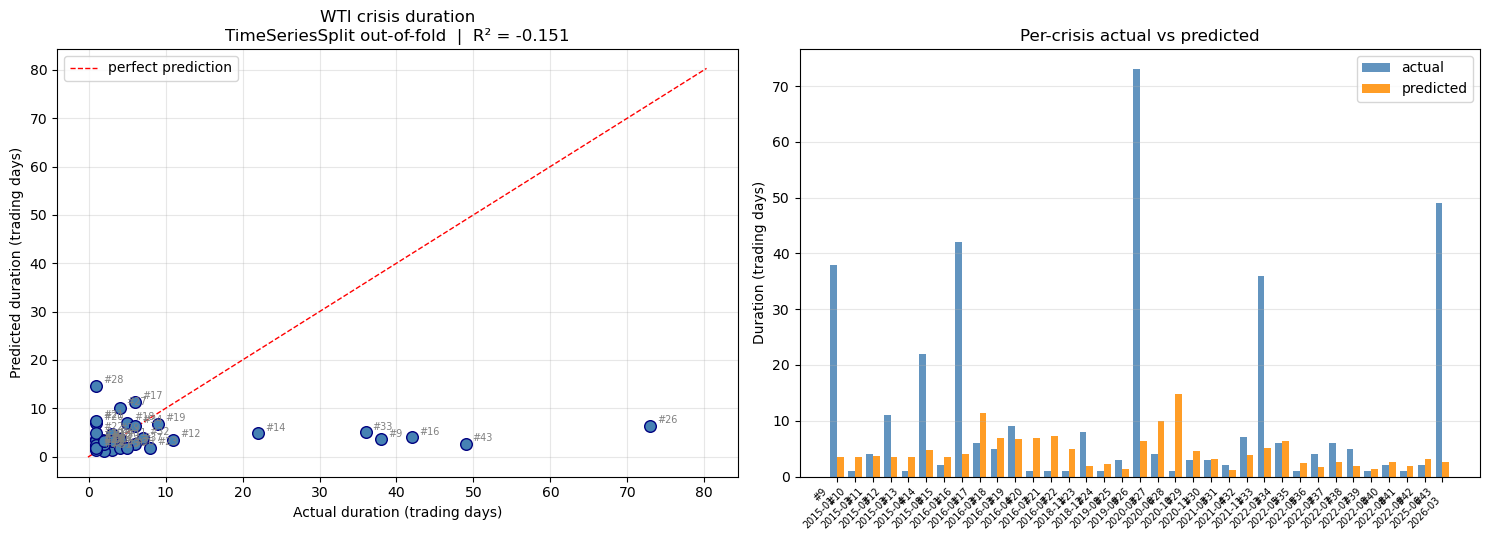

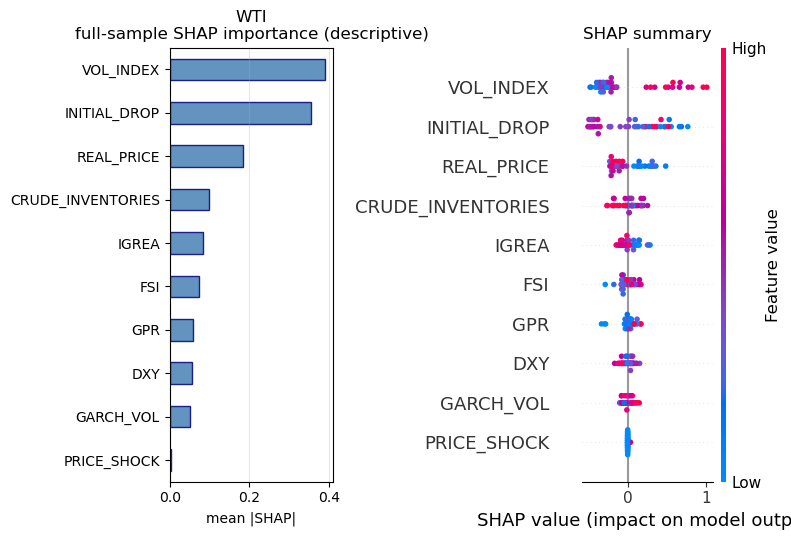


Brent [trading days]   n=47 crises, 10 features, log target
Evaluated on 35/47 crises; earliest 12 are training-only by construction (first evaluable 2016-12-02).
  [full features, log target]  n=35  RMSE=14.4d  MAE=5.6d  R2=0.094  MAPE=100% (diagnostic)  SMAPE=71%
  [full features, raw target]  n=35  RMSE=15.7d  MAE=9.6d  R2=-0.068  MAPE=320% (diagnostic)  SMAPE=105%
  [nested SHAP (top 4)]  n=35  RMSE=14.4d  MAE=6.6d  R2=0.099  MAPE=155% (diagnostic)  SMAPE=83%
  [nested VIF-trim]  n=35  RMSE=14.0d  MAE=5.9d  R2=0.145  MAPE=120% (diagnostic)  SMAPE=76%
  1 of 5 folds had too few training rows for stable VIF and used all 10 features.
  VIF-retained feature frequency: {'FSI': '5/5', 'IGREA': '5/5', 'PRICE_SHOCK': '5/5', 'INITIAL_DROP': '5/5', 'REAL_PRICE': '4/5', 'VOL_INDEX': '2/5', 'DXY': '1/5', 'GPR': '1/5', 'CRUDE_INVENTORIES': '1/5', 'GARCH_VOL': '1/5'}

Naive baselines (same forward-chaining CV):
                          RMSE     MAE     R2
label                                 

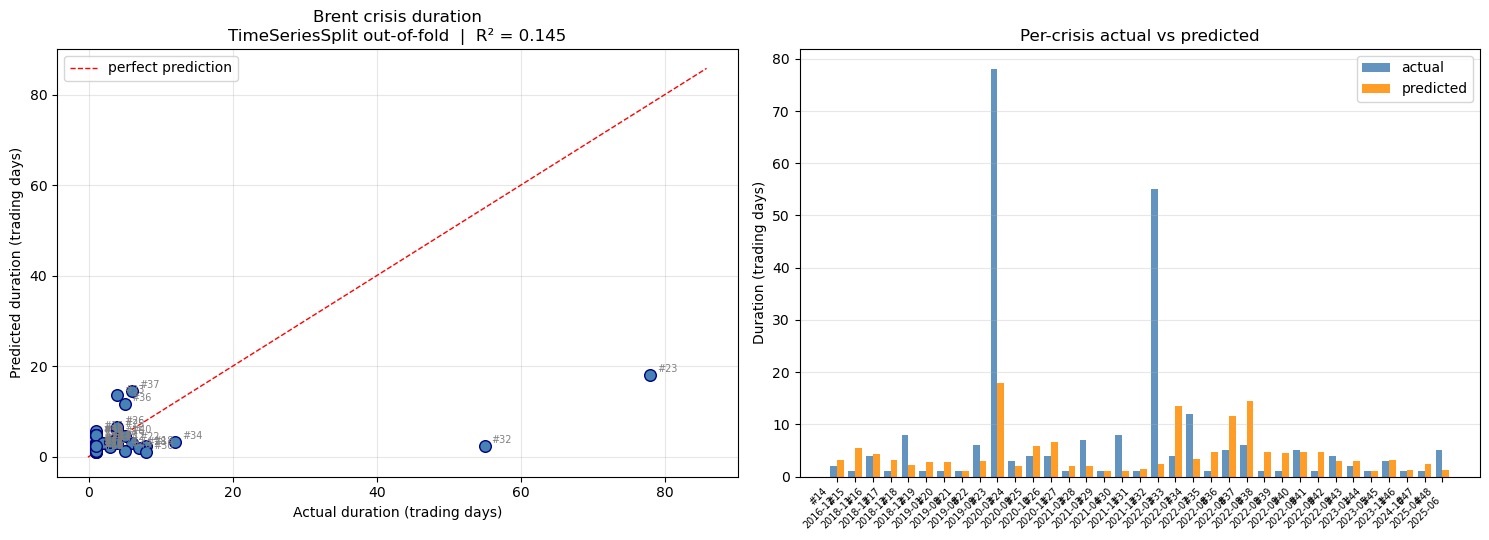

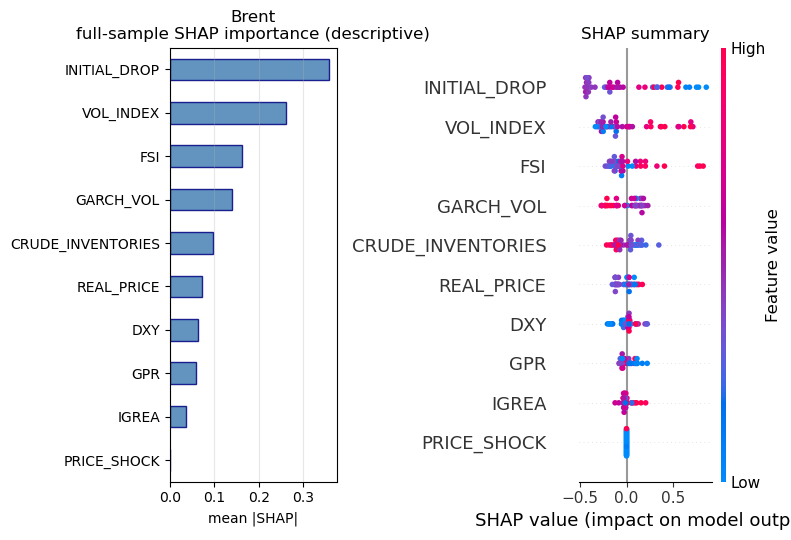


Gold [trading days]   n=20 crises, 11 features, log target
Evaluated on 15/20 crises; earliest 5 are training-only by construction (first evaluable 2013-06-21).
  [full features, log target]  n=15  RMSE=22.4d  MAE=13.4d  R2=-0.082  MAPE=256% (diagnostic)  SMAPE=86%
  [full features, raw target]  n=15  RMSE=22.3d  MAE=17.2d  R2=-0.076  MAPE=519% (diagnostic)  SMAPE=103%
  [nested SHAP (top 4)]  n=15  RMSE=22.2d  MAE=14.2d  R2=-0.063  MAPE=303% (diagnostic)  SMAPE=87%
  [nested VIF-trim]  n=15  RMSE=21.0d  MAE=13.2d  R2=0.047  MAPE=292% (diagnostic)  SMAPE=88%
  3 of 5 folds had too few training rows for stable VIF and used all 11 features.
  VIF-retained feature frequency: {'FSI': '5/5', 'IGREA': '5/5', 'PRICE_SHOCK': '5/5', 'EPU': '5/5', 'INITIAL_DROP': '5/5', 'VOL_INDEX': '4/5', 'DXY': '3/5', 'GPR': '3/5', 'REAL_PRICE': '3/5', 'GARCH_VOL': '3/5', 'GARCH_PERSISTENCE': '3/5'}

Naive baselines (same forward-chaining CV):
                          RMSE     MAE     R2
label               

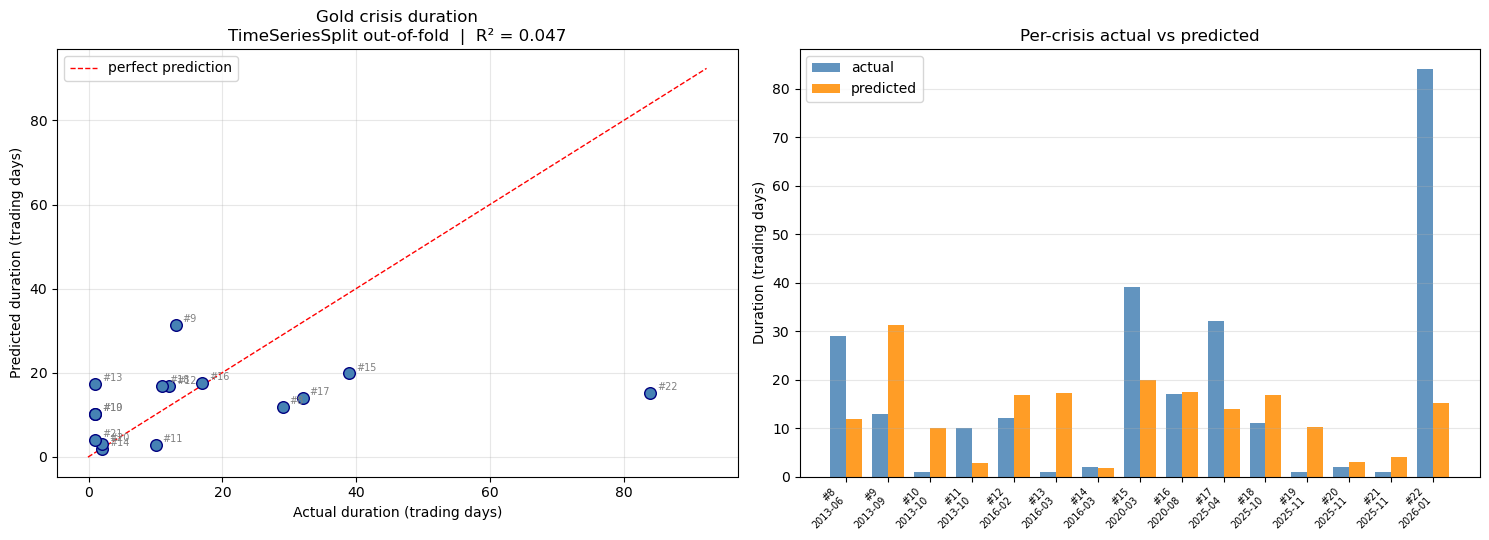

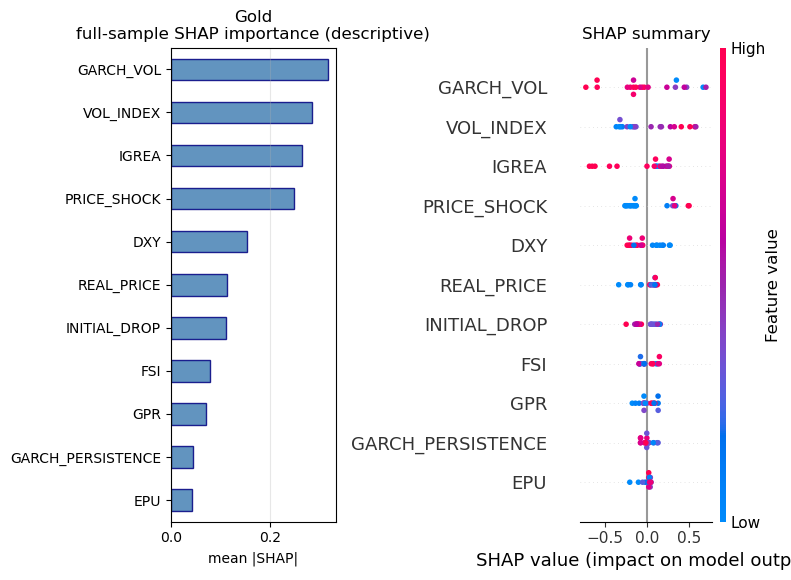


HRW Wheat [trading days]   n=32 crises, 12 features, log target
Evaluated on 25/32 crises; earliest 7 are training-only by construction (first evaluable 2011-04-28).
  [full features, log target]  n=25  RMSE=31.2d  MAE=11.7d  R2=-0.103  MAPE=116% (diagnostic)  SMAPE=83%
  [full features, raw target]  n=25  RMSE=31.5d  MAE=13.2d  R2=-0.120  MAPE=220% (diagnostic)  SMAPE=85%
  [nested SHAP (top 4)]  n=25  RMSE=31.3d  MAE=12.7d  R2=-0.109  MAPE=145% (diagnostic)  SMAPE=96%
  [nested VIF-trim]  n=25  RMSE=30.5d  MAE=12.0d  R2=-0.054  MAPE=148% (diagnostic)  SMAPE=88%
  2 of 5 folds had too few training rows for stable VIF and used all 12 features.
  VIF-retained feature frequency: {'FSI': '5/5', 'IGREA': '5/5', 'PRICE_SHOCK': '5/5', 'INITIAL_DROP': '5/5', 'WTI_REAL': '4/5', 'REAL_PRICE': '3/5', 'VOL_INDEX': '2/5', 'DXY': '2/5', 'GPR': '2/5', 'WHEAT_SUR': '2/5', 'GARCH_VOL': '2/5', 'GARCH_PERSISTENCE': '2/5'}

Naive baselines (same forward-chaining CV):
                          RMSE     M

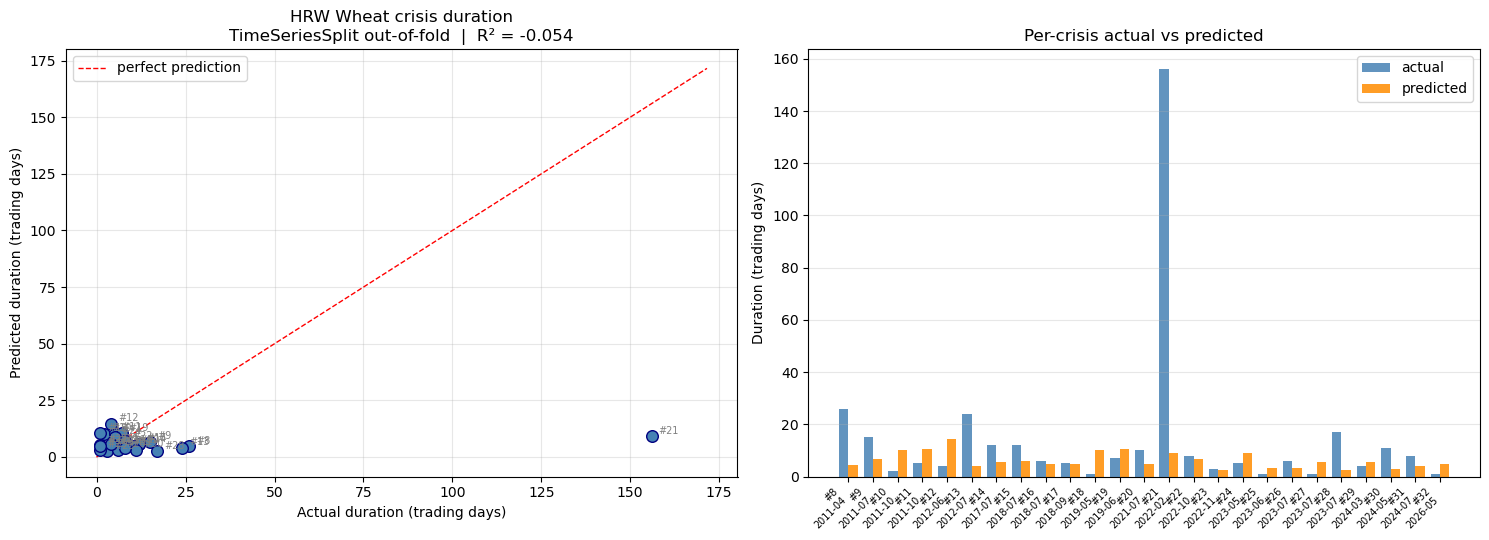

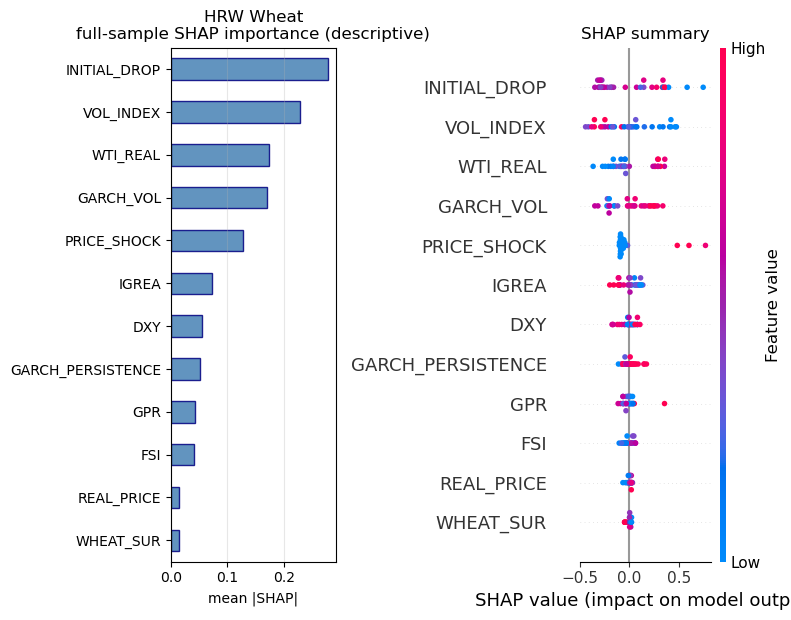


SRW Wheat [trading days]   n=46 crises, 12 features, log target
Evaluated on 35/46 crises; earliest 11 are training-only by construction (first evaluable 2011-03-18).
  [full features, log target]  n=35  RMSE=13.7d  MAE=8.3d  R2=-0.150  MAPE=177% (diagnostic)  SMAPE=95%
  [full features, raw target]  n=35  RMSE=14.0d  MAE=9.8d  R2=-0.203  MAPE=320% (diagnostic)  SMAPE=104%
  [nested SHAP (top 4)]  n=35  RMSE=14.0d  MAE=8.2d  R2=-0.194  MAPE=162% (diagnostic)  SMAPE=92%
  [nested VIF-trim]  n=35  RMSE=13.6d  MAE=7.8d  R2=-0.124  MAPE=130% (diagnostic)  SMAPE=88%
  1 of 5 folds had too few training rows for stable VIF and used all 12 features.
  VIF-retained feature frequency: {'FSI': '5/5', 'IGREA': '5/5', 'PRICE_SHOCK': '5/5', 'INITIAL_DROP': '5/5', 'GPR': '3/5', 'WTI_REAL': '3/5', 'VOL_INDEX': '1/5', 'DXY': '1/5', 'REAL_PRICE': '1/5', 'WHEAT_SUR': '1/5', 'GARCH_VOL': '1/5', 'GARCH_PERSISTENCE': '1/5'}

Naive baselines (same forward-chaining CV):
                          RMSE     MAE

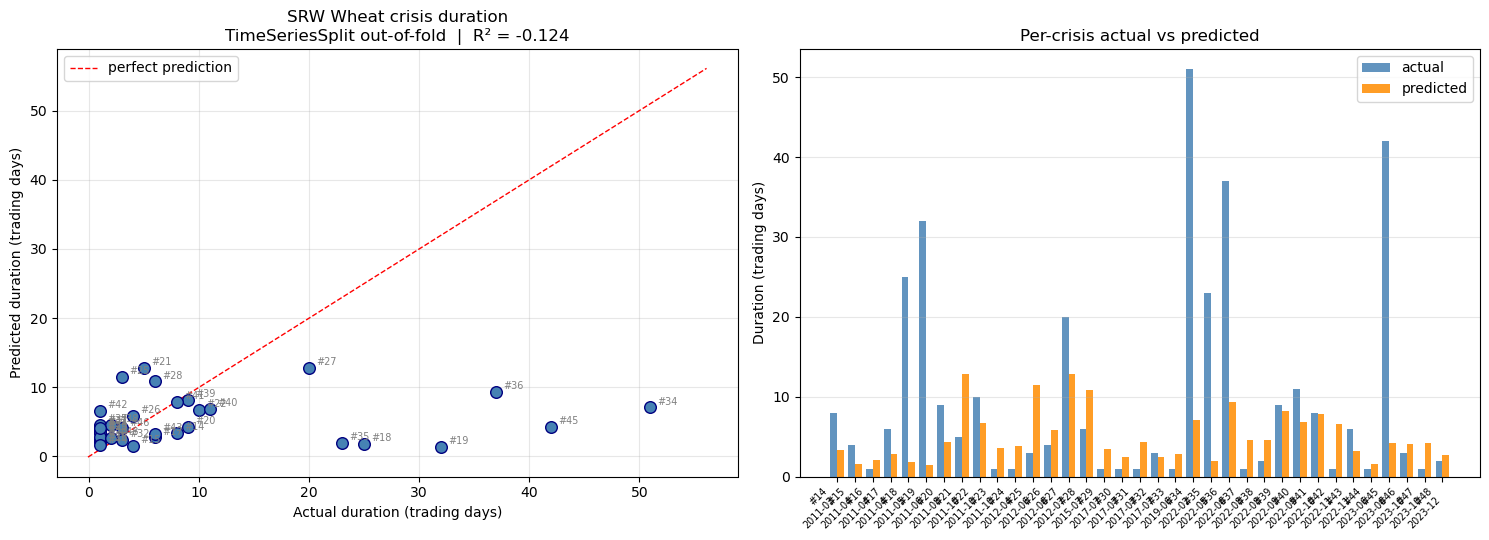

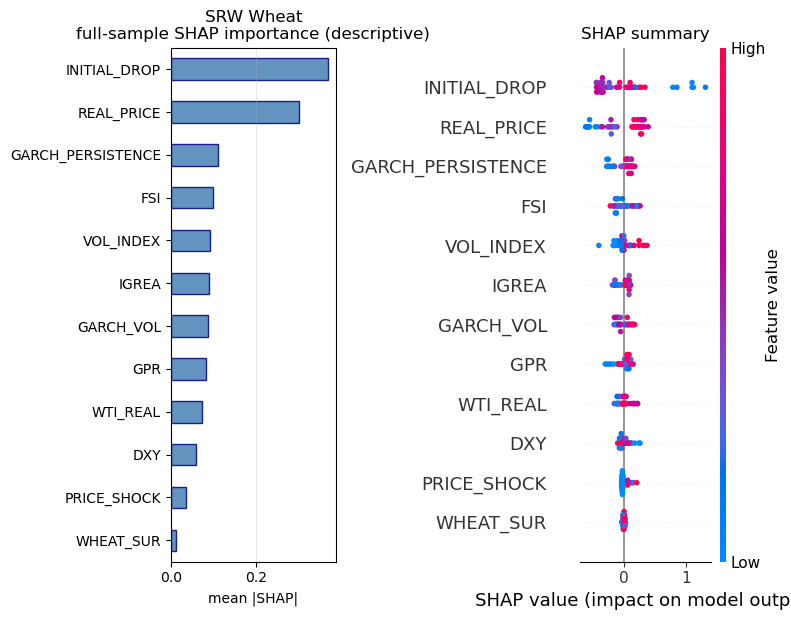

In [33]:
# ── Run the suite on the primary (trading-day) target  (SLOW) ──────────
VALIDATION = {}
for c in COMMODITIES:
    VALIDATION[c.key] = validate(c, target="trading", make_plots=True)

### 9.3 Assembled results

In [34]:
KEEP = ["n_crises", "n_features", "target_transform", "headline_variant",
        "r2_full", "r2_shap", "r2_vif", "r2_headline", "ci_low", "ci_high",
        "ci_crosses_zero", "perm_p", "perm_beats_pct", "wilcoxon_p",
        "mae_model", "mae_naive", "r2_naive_mean", "r2_naive_median",
        "tuned_r2_mean", "tuning_helps", "r2_declustered", "holdout_r2", "holdout_mae"]

summary = pd.DataFrame([{k: VALIDATION[c.key].get(k) for k in KEEP}
                        | {"commodity": c.label} for c in COMMODITIES]).set_index("commodity")

def verdict(r) -> str:
    """Single significance verdict per commodity, from a stated rule."""
    sig = (r["perm_p"] < ALPHA) + (r["wilcoxon_p"] < ALPHA) + (not r["ci_crosses_zero"])
    if r["r2_headline"] <= 0:            return "no signal (R2 <= 0)"
    if sig >= 2:                         return "signal (>=2 of 3 tests)"
    if sig == 1:                         return "inconclusive (1 of 3 tests)"
    return "no signal (0 of 3 tests)"

summary["verdict"] = summary.apply(verdict, axis=1)
summary["beats_all_naive"] = (summary["r2_headline"] > summary[
    ["r2_naive_mean", "r2_naive_median"]].max(axis=1))

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("=== HEADLINE RESULTS (trading-day target) ===\n")
print(summary[["n_crises", "n_features", "headline_variant", "r2_headline",
               "ci_low", "ci_high", "perm_p", "wilcoxon_p", "verdict"]].to_string())
print("\n=== Model vs naive ===\n")
print(summary[["r2_headline", "r2_naive_mean", "r2_naive_median", "beats_all_naive",
               "mae_model", "mae_naive"]].to_string())
print("\n=== Robustness ===\n")
print(summary[["r2_full", "r2_shap", "r2_vif", "tuned_r2_mean", "tuning_helps",
               "r2_declustered", "holdout_r2", "holdout_mae"]].to_string())

summary.to_csv(f"{RESULTS_DIR}/summary_trading.csv")
print(f"\nSaved -> {RESULTS_DIR}/summary_trading.csv")
print("\nNOTE: feature counts differ across commodities, so R2 is NOT strictly")
print("like-for-like between rows. Compare each against its own naive baselines.")

=== HEADLINE RESULTS (trading-day target) ===

           n_crises  n_features headline_variant  r2_headline  ci_low  ci_high  perm_p  wilcoxon_p                  verdict
commodity                                                                                                                  
WTI              43          10             full       -0.151  -0.278   -0.020   0.766       0.114      no signal (R2 <= 0)
Brent            47          10              vif        0.145  -1.338    0.309   0.015       0.023  signal (>=2 of 3 tests)
Gold             20          11              vif        0.047  -1.187    0.390   0.035       0.036  signal (>=2 of 3 tests)
HRW Wheat        32          12              vif       -0.054  -1.079   -0.014   0.124       0.298      no signal (R2 <= 0)
SRW Wheat        46          12              vif       -0.124  -0.486    0.122   0.219       0.054      no signal (R2 <= 0)

=== Model vs naive ===

           r2_headline  r2_naive_mean  r2_naive_median  beat

### 9.4 Target-grid robustness `CHANGED`

The whole battery re-run on the **calendar-day** target. If conclusions are robust
to the definition, the verdict column should not move. This is the check that
replaces the original's silent choice between two conflicting duration units.

Plots are suppressed here — only the comparison table matters.

In [35]:
VALIDATION_CAL = {c.key: validate(c, target="calendar", make_plots=False) for c in COMMODITIES}

cal = pd.DataFrame([{k: VALIDATION_CAL[c.key].get(k) for k in KEEP}
                    | {"commodity": c.label} for c in COMMODITIES]).set_index("commodity")
cal["verdict"] = cal.apply(verdict, axis=1)

cmp = pd.DataFrame({
    "R2_trading":  summary["r2_headline"], "R2_calendar": cal["r2_headline"],
    "permp_trading": summary["perm_p"],    "permp_calendar": cal["perm_p"],
    "verdict_trading": summary["verdict"], "verdict_calendar": cal["verdict"],
})
cmp["verdict_stable"] = cmp["verdict_trading"] == cmp["verdict_calendar"]
print("=== Trading-day vs calendar-day target ===\n")
print(cmp.to_string())
n_stable = int(cmp["verdict_stable"].sum())
print(f"\nVerdict unchanged for {n_stable} of {len(cmp)} commodities.")
print("Where it changes, the qualitative conclusion depends on the duration")
print("definition and BOTH must be reported in the paper.")
cal.to_csv(f"{RESULTS_DIR}/summary_calendar.csv")
cmp.to_csv(f"{RESULTS_DIR}/target_grid_sensitivity.csv")
print(f"Saved -> {RESULTS_DIR}/summary_calendar.csv, {RESULTS_DIR}/target_grid_sensitivity.csv")


WTI [calendar days]   n=43 crises, 10 features, log target
Evaluated on 35/43 crises; earliest 8 are training-only by construction (first evaluable 2015-01-13).
  [full features, log target]  n=35  RMSE=26.2d  MAE=13.5d  R2=-0.178  MAPE=185% (diagnostic)  SMAPE=97%
  [full features, raw target]  n=35  RMSE=27.7d  MAE=19.7d  R2=-0.311  MAPE=548% (diagnostic)  SMAPE=117%
  [nested SHAP (top 4)]  n=35  RMSE=27.4d  MAE=14.9d  R2=-0.289  MAPE=290% (diagnostic)  SMAPE=101%


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsm

  [nested VIF-trim]  n=35  RMSE=27.0d  MAE=13.2d  R2=-0.244  MAPE=154% (diagnostic)  SMAPE=89%
  1 of 5 folds had too few training rows for stable VIF and used all 10 features.
  VIF-retained feature frequency: {'FSI': '5/5', 'IGREA': '5/5', 'REAL_PRICE': '5/5', 'PRICE_SHOCK': '5/5', 'GARCH_VOL': '5/5', 'INITIAL_DROP': '5/5', 'CRUDE_INVENTORIES': '2/5', 'VOL_INDEX': '1/5', 'DXY': '1/5', 'GPR': '1/5'}

Naive baselines (same forward-chaining CV):
                         RMSE    MAE     R2
label                                      
naive: training mean   24.980 14.820 -0.069
naive: training median 26.553 12.986 -0.208
naive: previous crisis 32.488 18.595 -1.095

Headline variant: full (R2=-0.178)
Block-bootstrap 95% percentile CI on R2: [-0.304, -0.047] (n=10000, block length=3)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsm

Block permutation test on the VIF variant: real R2=-0.244 beats 21.0% of 200 block shuffles (null mean -0.208); exact p=0.7910
Wilcoxon (model |error| < naive |error|): W=228.5, p=0.0783  [model MAE 13.5d vs naive 14.8d]
Hyperparameter search across 5 seed(s): R2 mean=-0.227 range [-0.230, -0.227] vs untuned VIF -0.244 -> tuning helps
  [confirmatory holdout (last 6, evaluated once)]  n=6  RMSE=27.3d  MAE=12.1d  R2=-0.172  MAPE=69% (diagnostic)  SMAPE=67%
             actual  predicted
  crisis_id                   
  38              7          6
  39              1          2
  40              2          5
  41              1          2
  42              2          2
  43             70          3
  R2 on 6 points is a noisy generalisation check, not a precise metric; absolute errors are the meaningful figure. Features chosen on dev only: ['FSI', 'IGREA', 'REAL_PRICE', 'PRICE_SHOCK', 'GARCH_VOL', 'INITIAL_DROP']


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/opt/anaconda3/lib/python3.13/site-packages/statsm

De-clustering: dropped 4 crisis(es) starting within 5 days of another; R2 -0.244 -> -0.209 (N 43 -> 39)

Brent [calendar days]   n=47 crises, 10 features, log target
Evaluated on 35/47 crises; earliest 12 are training-only by construction (first evaluable 2016-12-02).
  [full features, log target]  n=35  RMSE=21.4d  MAE=8.3d  R2=0.091  MAPE=129% (diagnostic)  SMAPE=78%
  [full features, raw target]  n=35  RMSE=22.7d  MAE=13.2d  R2=-0.024  MAPE=365% (diagnostic)  SMAPE=109%
  [nested SHAP (top 4)]  n=35  RMSE=22.4d  MAE=10.0d  R2=0.005  MAPE=213% (diagnostic)  SMAPE=91%
  [nested VIF-trim]  n=35  RMSE=21.0d  MAE=8.5d  R2=0.127  MAPE=145% (diagnostic)  SMAPE=82%
  1 of 5 folds had too few training rows for stable VIF and used all 10 features.
  VIF-retained feature frequency: {'FSI': '5/5', 'IGREA': '5/5', 'PRICE_SHOCK': '5/5', 'INITIAL_DROP': '5/5', 'REAL_PRICE': '4/5', 'VOL_INDEX': '2/5', 'DXY': '1/5', 'GPR': '1/5', 'CRUDE_INVENTORIES': '1/5', 'GARCH_VOL': '1/5'}

Naive baselines (same

## 10. Auto-generated findings and limitations

In [37]:
def findings() -> str:
    L = ["### Findings\n"]
    sel_txt = ", ".join(f"{s['commodity']} {s['spec']} K={s['K']}"
                        + (f" (BIC rank {s['bic_rank']})" if s["overrode_bic"] else "")
                        for s in SELECTED.values())
    L.append(f"**Volatility models.** Selected specifications: {sel_txt}. "
             f"{sum(s['overrode_bic'] for s in SELECTED.values())} of {len(SELECTED)} "
             f"required a BIC concession to pass the residual clustering test.")
    if two_state:
        L.append(f"**Regimes.** Two-state structure supported for "
                 f"{[CM[k].label for k in two_state]}; "
                 f"{[CM[k].label for k in single]} selected single-regime models, so they "
                 f"carry no regime probability and no regime episodes.")
    for grp, name in [(summary[summary["verdict"].str.startswith("signal")], "show a signal"),
                      (summary[summary["verdict"].str.startswith("inconclusive")], "are inconclusive"),
                      (summary[summary["verdict"].str.startswith("no signal")], "show no signal")]:
        if len(grp):
            L.append(f"**Duration prediction.** {grp.index.tolist()} {name} "
                     f"(R² {grp['r2_headline'].min():.3f} to {grp['r2_headline'].max():.3f}).")
    L.append(f"**Target definition.** The trading/calendar verdict agrees for "
             f"{int(cmp['verdict_stable'].sum())} of {len(cmp)} commodities"
             + ("." if cmp["verdict_stable"].all() else
                f"; it differs for {cmp.index[~cmp['verdict_stable']].tolist()}, which must "
                f"be reported as a sensitivity rather than resolved."))
    fm = [i for i, r in summary.iterrows() if r["holdout_mae"] == r["holdout_mae"]]
    if fm:
        L.append("**Recurring failure mode.** Across commodities the model compresses "
                 "predictions toward a typical duration and badly under-predicts the rare "
                 "long episodes. Since those are the events of practical interest, the "
                 "holdout results support no claim of skill on extreme events.")
    return "\n\n".join(L)

def limitations() -> str:
    crossing = summary.index[summary["ci_crosses_zero"]].tolist()
    return "\n\n".join([
        "### Limitations",
        f"1. **Sample size.** Each commodity contributes "
        f"{summary['n_crises'].min()}–{summary['n_crises'].max()} crises. "
        "The earliest validation fold is training-only, and bootstrap intervals are wide"
        + (f", crossing zero for {crossing}." if crossing else "."),
        f"2. **Not like-for-like.** Feature counts vary from "
        f"{summary['n_features'].min()} to {summary['n_features'].max()}, and commodities "
        "use different trading calendars. Each model should therefore be compared with "
        "its own baselines, not with another commodity's R².",
        "3. **Crisis construct.** Percentile-based crises and Markov-switching regimes "
        "represent different constructs with limited day-set overlap. Results describe "
        "the percentile-based construct.",
        "4. **Full-sample labels.** Crisis boundaries use a full-sample volatility fit and "
        "could not have been known in real time. Predictors are causal, but labels are not.",
        "5. **Resampling scope.** Bootstrap and permutation procedures resample fixed "
        "out-of-fold predictions rather than rerunning the complete feature-selection pipeline, "
        "so selection uncertainty is understated.",
        "6. **WHEAT_SUR limitations.** This annual series includes a one-year publication lag, "
        "a forecast for its final market year, and revisions published at different times "
        "across countries.",
        "7. **Data revisions.** EIA, LBMA, Yahoo, FRED, and GPR inputs may be revised. "
        "A rerun may therefore not reproduce the reported figures exactly; the run date "
        "should accompany all reported tables."
    ])


print(findings())
print()
print(limitations())

### Findings


**Volatility models.** Selected specifications: WTI gjrGARCH-sstd K=1 (BIC rank 2), Brent gjrGARCH-sstd K=2 (BIC rank 3), Gold sGARCH-std K=1, HRW Wheat eGARCH-sstd K=1, SRW Wheat sGARCH-sstd K=1. 2 of 5 required a BIC concession to pass the residual clustering test.

**Regimes.** Two-state structure supported for ['Brent']; ['WTI', 'Gold', 'HRW Wheat', 'SRW Wheat'] selected single-regime models, so they carry no regime probability and no regime episodes.

**Duration prediction.** ['Brent', 'Gold'] show a signal (R² 0.047 to 0.145).

**Duration prediction.** ['WTI', 'HRW Wheat', 'SRW Wheat'] show no signal (R² -0.151 to -0.054).

**Target definition.** The trading/calendar verdict agrees for 4 of 5 commodities; it differs for ['Gold'], which must be reported as a sensitivity rather than resolved.

**Recurring failure mode.** Across commodities the model compresses predictions toward a typical duration and badly under-predicts the rare long episodes. Since those are the e

In [38]:
# ── Manifest: everything a reader needs to place these numbers in time ──
import platform, datetime as _dt

manifest = {
    "generated_utc": _dt.datetime.now(_dt.timezone.utc).isoformat(timespec="seconds"),
    "python": sys.version.split()[0], "platform": platform.platform(),
    "packages": {m.__name__: getattr(m, "__version__", "?")
                 for m in (pd, np, xgb, shap)},
    "msgarch_version": str(ro.r('as.character(packageVersion("MSGARCH"))')[0]),
    "window": {"start": START, "end": END},
    "crisis_percentile": CRISIS_PCTILE, "cpi_base": CPI_BASE,
    "feature_window_obs": FEATURE_WINDOW, "n_permutations": N_PERMUTATIONS,
    "n_bootstrap": N_BOOTSTRAP, "seeds": SEEDS, "quick_mode": QUICK,
    "selected_models": {k: {"spec": v["spec"], "K": v["K"], "bic_rank": v["bic_rank"]}
                        for k, v in SELECTED.items()},
    "n_crises": {c.key: int(len(DESIGN[c.key])) for c in COMMODITIES},
    "observations": {c.key: int(len(SERIES[c.key]["ret"])) for c in COMMODITIES},
}
with open(f"{RESULTS_DIR}/run_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(json.dumps(manifest, indent=2, default=str))
print(f"\nSaved -> {RESULTS_DIR}/run_manifest.json")

{
  "generated_utc": "2026-09-13T18:23:12+00:00",
  "python": "3.13.9",
  "platform": "macOS-26.6.2-arm64-arm-64bit-Mach-O",
  "packages": {
    "pandas": "2.3.3",
    "numpy": "2.3.5",
    "xgboost": "3.4.0",
    "shap": "0.52.0"
  },
  "msgarch_version": "2.51",
  "window": {
    "start": "2010-01-01",
    "end": "2026-07-01"
  },
  "crisis_percentile": 0.9,
  "cpi_base": "2026-06",
  "feature_window_obs": 5,
  "n_permutations": 200,
  "n_bootstrap": 10000,
  "seeds": [
    7,
    42,
    123,
    2024,
    99
  ],
  "quick_mode": false,
  "selected_models": {
    "wti": {
      "spec": "gjrGARCH-sstd",
      "K": 1,
      "bic_rank": 2
    },
    "brent": {
      "spec": "gjrGARCH-sstd",
      "K": 2,
      "bic_rank": 3
    },
    "gold": {
      "spec": "sGARCH-std",
      "K": 1,
      "bic_rank": 1
    },
    "hrw": {
      "spec": "eGARCH-sstd",
      "K": 1,
      "bic_rank": 1
    },
    "srw": {
      "spec": "sGARCH-sstd",
      "K": 1,
      "bic_rank": 1
    }
  },
  "n_c